# Project SILAW

In [1]:
pip install gdown pydrive geopandas shapely opencv-python adjustText

Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
from shapely.geometry import box
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import Point
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.colorbar import ColorbarBase
from shapely.geometry import Point, box
from rasterio.windows import from_bounds
import os
import shutil
import rasterio
from rasterio.merge import merge
import glob
import os

## Data Validation

In [3]:
viirs_file_path = "E:/SILAW/NightLights"
viirs_files = os.listdir(viirs_file_path)

for file in viirs_files:
  viirs_file = os.path.join(viirs_file_path, file)
  with rasterio.open(viirs_file) as viirs_raster:
    print(viirs_raster.meta)
    out_image = viirs_raster.read()

    viirs_data = out_image[0]
    viirs_data[viirs_data < 0] = np.nan

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2338, 'height': 3805, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.004491576420597608, 0.0, 115.99945263835382,
       0.0, -0.004491576420597608, 21.586516277392104)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2361, 'height': 3846, 'count': 1, 'crs': CRS.from_epsg(3123), 'transform': Affine(494.29589709905565, 0.0, -55637.12846947601,
       0.0, -494.29589709905565, 2398046.151485892)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2361, 'height': 3857, 'count': 1, 'crs': CRS.from_epsg(32651), 'transform': Affine(494.32010763507225, 0.0, -278532.9714011514,
       0.0, -494.32010763507225, 2403435.190945331)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2361, 'height': 3857, 'count': 1, 'crs': CRS.from_epsg(32651), 'transform': Affine(494.32010763507225, 0.0, -278532.9714011514,
       0.0, -494.32010763507225, 2403435.190945331)}
{'driver': 'G

In [4]:
mpa_shapefile = "E:/SILAW/MarineProtectedAreas/MarineProtectedAreas.shp"
mpas = gpd.read_file(mpa_shapefile)

mpas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
pip install summarytools

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
from summarytools import dfSummary

In [7]:
dfSummary(mpas)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,ID[float64],Mean (sd) : 3347.4 (129.0)min < med < max:2754.0 < 3352.0 < 3533.0IQR (CV) : 181.0 (26.0),339 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAAC1klEQVR4nO3dMW/aUBSG4e/igOzEMkJpko2lYyUGxiz9B/2xWbt1YOgWKUOXTtmiIDDCDcUYd0kiRUoBX8eNj/o++8F3eLnC2LJdWZYC2q7z3gsADnH03gvAS865SFKvxkd0JG09Z9dlWT74Hrjm2ncem1BbxDkXnZ6efkmSZOAzXxRFN8uyj3Ec/+x0OnnV+cViMXPOXfnEWnft+45NqO3SS5JkcHl5+dDv91dVh29vbwc3Nzdn4/H4x8XFxazKbJqm4WQyGUyn054kn13Ve+2HHJtQW6jf76/Oz89/VZ2bzWaRJJ2cnHjNS4o8Zl7wXfu+Y3MyBRMIFSYQKkwgVJhAqDCBUGECocIE/kfFs6IoupIS55zPeLLdbrtvvKRnhApJUpZl3TzPR8PhMAiCoPJVsTzPw6IoPq1Wq2+SfP7w34lQIUlar9dHYRgej8fjVdXLr9Lz5dvjzWYTNLE+QsULvpdfny7fNoWTKZhAqDCBUGECocIEQoUJhAoTCBUmECpMIFSYQKgwgVBhAqHCBEKFCYQKEwgVJhAqTCBUmECoMIFQYQKhwgRChQmEChMIFSYQKkwgVJhAqDCBUGECocIEQoUJhAoTCBUm8HzUBtR4y3Kjjxe3jFDfWJ23LDf9eHHLCPXteb9luenHi1tGqA3xecty048Xt4yTKZhAqDCBUGECocIEQoUJhAoTCBUmECpMIFSYQKgwgVBhAtf6/4Jb9dqFUF/BrXrtszfUGjuLJK3LsnzwnH1P3KrXMjtDrbOzSNJisZg5566Mxsqtei2yb0f13lnSNA0nk8lgOp32JHmF+p/u5njFQb9RfXaWR967S93dfD6fL51zXyVV+oI94oSoZQ4KNU3TsOoHp2kaFkVxJClxzlVemKQkjuOz0Wi0iaLod5XB+XweX19ffx4Ohx+CIKgc6tMJ0f39/feqs8vlMpSkLMvCu7u74381a/nYh/T1B9T3Mduh/WiPAAAAAElFTkSuQmCC"">",0(0.0%)
2,REGION[object],1. Asia,339 (100.0%),,0(0.0%)
3,SUBREGION[object],1. Southeast Asia,339 (100.0%),,0(0.0%)
4,COUNTRY[object],1. Philippines,339 (100.0%),,0(0.0%)
5,SITE_CODE[float64],Mean (sd) : 296657.1 (53087.2)min < med < max:845.0 < 305980.0 < 312026.0IQR (CV) : 5728.0 (5.6),339 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABlUlEQVR4nO3XPWobURSG4XuDEBowd5AGtBj1ab1Yt+m1GxGNMJFwockCjP/GDspnnqe9cw6neJup0zQV+N/9uPUB8B6LWx/A91Fr7Uopy5njT9M0nV96FCpfotbaDcNw31pbz5k/nU6/a60PL8UqVL7KsrW23u12577vLx8ZHMdxtd/v14fDYVlKESr/Xt/3l+12+2fGaPfao58pIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCIu3Pqi1dqWU5cz9T9M0nWfOfson7y7lhrfz3Kuh1lq7YRjuW2vrOcuPx+NjrfVXKeUy67r5VpvN5mff93dzF9zw9lTter0uxnFcfXTwPTN/AXUqP4TkkPVTAAAAAElFTkSuQmCC"">",0(0.0%)
6,IUCNCAT_CO[object],1. VI2. Unknown3. V4. II5. IV,169 (49.9%)154 (45.4%)12 (3.5%)2 (0.6%)2 (0.6%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABzCAYAAACPdnBjAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACN0lEQVR4nO3bQWrbUBiF0V9BhGYiYQRejBeRxXYR2o0x1qAJmbiDpqNY0BjpCtFzVvAIH1Yk3m1ut1tBwtPWB+D/ITZixEZMU1UvVfW89UF25uN2u71tfYi9aYdheO267rD1QfZkmqZL0zQ/Bfc9bdd1h9Pp9Nb3/fvWh9mD6/X6YxzHw/l8fq4qsX1DW1XV9/378Xj8tfVhduRl6wPskRcEYsRGjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYiOmrfpzbWbrg+yFv9Xj2mmaLuM4Hsq1mX82TdOlqj62PsfeuBb+GNfCH9DYjZLiBYEYj9F5HpULs66aYUG1POuqOyyo1mFdNc+noIV5QSBGbMSIjRixESM2YsRGjNiIERsxYiNGbMSIjRixESM2Yqyr7vD3WId11QwLquW5Fj7PtfCFWVcR4wWBmLnHqEcIi7u7rrIsYg1f1lWWRaxlbl3lMwiL84JAjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYiNGbMR8WVdZFrGWu+sqyyLW4Fo4MdZVxPz9ZSu/ZKytHYbhtarKwIW1PXVdd/hcV1nFsyrf2YgRGzFiI0ZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERIzZixEZM+7mkqrKmYmU2CMRYVxHjl40Y6ypirKuI8emDGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxFhXEWODQIx1FTH+ZyNGbMT8Bom3zmx3YHkUAAAAAElFTkSuQmCC"">",0(0.0%)
7,LAT[float64],Mean (sd) : 6.0 (5.2)min < med < max:0.0 < 9.3 < 20.6IQR (CV) : 10.0 (1.1),199 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACmklEQVR4nO3dsW7aUBiG4f8UggxU58ggkS03EKkDI3vXXGwuoQNDZ+4gWwRCRiG4gONOrVK1DXBMhD/nfeb8xhKv8ImPJbuyLA

In [8]:
if mpas.crs != viirs_raster.crs:
    mpas = mpas.to_crs(viirs_raster.crs)

In [9]:
mpas['valid_geometry'] = mpas.is_valid
invalid_mpas = mpas[~mpas['valid_geometry']]

mpas = mpas.buffer(0)

## Verifying Consistency

In [10]:
# Paths
mpa_file_path = "E:/SILAW/MarineProtectedAreas/MarineProtectedAreas.shp"
viirs_directory = "E:/SILAW/NightLights"

# Buffer distance for MPAs (10 km)
mpa_buffer_distance = 10000  # 10 km buffer

# Years to check
years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Initialize a list to store analysis results
consistency_results = []

# Check if the MPA shapefile exists
if os.path.exists(mpa_file_path):
    # Load the MPA shapefile and ensure geometries are valid
    mpa = gpd.read_file(mpa_file_path)
    mpa = mpa[mpa.is_valid]

    # Reproject MPA to UTM for consistency (EPSG:32651 for the Philippines)
    mpa_utm = mpa.to_crs("EPSG:32651")

    # Apply a 10 km buffer around each MPA polygon
    mpa_utm['geometry'] = mpa_utm.buffer(mpa_buffer_distance)

    # Calculate the total area of the buffered MPAs (in square meters)
    total_mpa_area = mpa_utm.geometry.area.sum()

    # Loop through each year and corresponding VIIRS file
    for year in years:
        viirs_file = f'VIIRS_{year}_Philippines.tif'
        viirs_file_path = os.path.join(viirs_directory, viirs_file)

        if os.path.exists(viirs_file_path):
            # Load the VIIRS raster file and get bounds/CRS
            with rasterio.open(viirs_file_path) as src:
                viirs_bounds = src.bounds
                viirs_crs = src.crs

                # Create a bounding box for the VIIRS data
                viirs_box = box(viirs_bounds.left, viirs_bounds.bottom, viirs_bounds.right, viirs_bounds.top)
                viirs_gdf = gpd.GeoDataFrame({'geometry': [viirs_box]}, crs=viirs_crs)

                # Reproject VIIRS data to UTM (EPSG:32651) for consistency in checking
                if viirs_crs != "EPSG:32651":
                    viirs_gdf = viirs_gdf.to_crs("EPSG:32651")

            # Ensure MPA and VIIRS data have the same CRS
            if mpa_utm.crs != viirs_gdf.crs:
                mpa_utm = mpa_utm.to_crs(viirs_gdf.crs)

            # Check if any part of the buffered MPA overlaps with the VIIRS bounding box
            overlap_exists = mpa_utm.intersects(viirs_gdf.loc[0, 'geometry']).any()

            # Store the result for each year
            result = {
                'year': year,
                'viirs_file': viirs_file,
                'mpa_file': mpa_file_path,
                'crs_match': mpa_utm.crs == viirs_gdf.crs,
                'overlap_exists': overlap_exists,
                'mpa_total_area_sqm': total_mpa_area
            }
            consistency_results.append(result)
        else:
            print(f"VIIRS file missing for year {year}")
else:
    print(f"MPA file missing: {mpa_file_path}")

# Convert the analysis results into a DataFrame for easy analysis
consistency_df = pd.DataFrame(consistency_results)
consistency_df.to_csv('E:/SILAW/Results/mpa_viirs_consistency_analysis.csv', index=False)


In [11]:
consistency_df

,year,viirs_file,mpa_file,crs_match,overlap_exists,mpa_total_area_sqm
0,2014,VIIRS_2014_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
1,2015,VIIRS_2015_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
2,2016,VIIRS_2016_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
3,2017,VIIRS_2017_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
4,2018,VIIRS_2018_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
5,2019,VIIRS_2019_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
6,2020,VIIRS_2020_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
7,2021,VIIRS_2021_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
8,2022,VIIRS_2022_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10
9,2023,VIIRS_2023_Philippines.tif,E:/SILAW/MarineProtectedAreas/MarineProtectedA...,True,True,6.241731e+10


Total MPAs: 339
Valid geometries: 339 / 339
Empty geometries: 0


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\3318290078.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


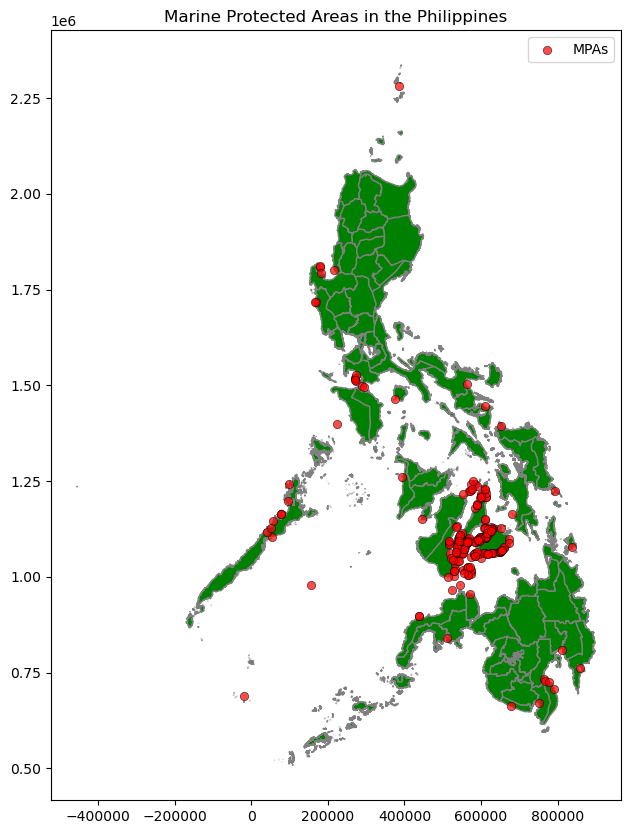

<Figure size 640x480 with 0 Axes>

In [12]:
# Load the MPA shapefile
mpa = gpd.read_file(mpa_file_path)

# Check if the shapefile is loaded correctly and not empty
if mpa.empty:
    print(f"MPA shapefile at {mpa_file_path} is empty or not loaded correctly.")
else:
    # Check validity of geometries and calculate counts for valid and empty geometries
    valid_geometries = mpa.is_valid.sum()
    empty_geometries = mpa.geometry.is_empty.sum()

    # Print the summary of total, valid, and empty geometries
    print(f"Total MPAs: {len(mpa)}")
    print(f"Valid geometries: {valid_geometries} / {len(mpa)}")
    print(f"Empty geometries: {empty_geometries}")

    # Reproject MPA to UTM (EPSG:32651) for consistent CRS and accurate spatial calculations
    mpa_projected = mpa.to_crs("EPSG:32651")

    # Filter valid geometries to avoid issues during plotting
    mpa_projected = mpa_projected[mpa_projected.is_valid & ~mpa_projected.geometry.is_empty]

    # Proceed with plotting if there are valid geometries
    if len(mpa_projected) > 0:
        # Load the shapefile for the Philippines basemap
        ph_basemap = gpd.read_file("E:/SILAW/PH_Basemap/phl_admbnda_adm2_psa_namria_20231106.shp")

        # Reproject the basemap to UTM (EPSG:32651)
        ph_basemap_utm = ph_basemap.to_crs("EPSG:32651")

        # Plot MPAs, 100 km buffers, and the basemap
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))

        # Plot the basemap
        ph_basemap_utm.plot(ax=ax, color='green', edgecolor='grey', label='Philippines Basemap')

        # Plot the MPAs
        mpa_projected.plot(ax=ax, color='red', alpha=0.7, label="MPAs", linewidth=0.5, edgecolor='black')

        # Customize and show the plot
        plt.title("Marine Protected Areas in the Philippines")
        plt.legend()
        plt.show()
        plt.savefig('E:/SILAW/Results_PH/PH_MPAS.png', bbox_inches='tight', dpi=300)

    else:
        print("No valid geometries to plot.")

## Yearly Analysis

In [13]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

def reproject_raster(src_file, dst_file, dst_crs):
    """Reproject a raster file to a new coordinate system."""
    with rasterio.open(src_file) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        with rasterio.open(dst_file, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest)

In [14]:
# Define the radiance thresholds for light pollution categories
HIGH_POLLUTION_THRESHOLD = 0.3  # High light pollution threshold
MODERATE_POLLUTION_THRESHOLD = 0.1  # Moderate light pollution threshold

# Weights for the risk score calculation
w1 = 0.5  # Weight for normalized radiance
w2 = 0.5  # Weight for environmental score

# Function to classify radiance levels
def classify_radiance_level(mean_radiance):
    """Classify radiance based on thresholds for high, moderate, and low light pollution."""
    if mean_radiance > HIGH_POLLUTION_THRESHOLD:
        return 'High Light Pollution'
    elif MODERATE_POLLUTION_THRESHOLD <= mean_radiance <= HIGH_POLLUTION_THRESHOLD:
        return 'Moderate Light Pollution'
    else:
        return 'Low Light Pollution'

In [15]:
# Function to calculate the environmental score
def calculate_environmental_score(row):
    """Calculate environmental score based on MPA attributes."""
    score = 0
    score += row.get('MARINE_EXI', 0) * 2  # Marine existing
    score += row.get('LITTORAL_E', 0) * 2  # Littoral existing
    score += row.get('CORAL_EXIS', 0) * 3  # Coral reef existing
    score += row.get('SEAGRASS_E', 0) * 2  # Seagrass existing
    score += row.get('MANGROVE_E', 0) * 2  # Mangrove existing
    score += row.get('REEF_AREA_', 0) / 1000  # Reef area size, normalizing by 1000

    max_possible_score = 2 + 2 + 3 + 2 + 2 + (max(row.get('REEF_AREA_', 0), 1) / 1000)

    return score / max_possible_score  # Normalize the environmental score

In [16]:
# Function to calculate risk score
def calculate_risk_score(normalized_radiance, environmental_score, w1=0.5, w2=0.5):
    """Calculate the risk score as a weighted sum of radiance and environmental score."""
    return round((normalized_radiance * w1 + environmental_score * w2), 2)

In [17]:
# Define the thresholds for risk score classification
def classify_risk_level(risk_score):
    """Classify risk score into Low, Medium, High, Very High, and Critical categories."""
    if risk_score <= 0.25:
        return 'Low Risk'
    elif 0.25 < risk_score <= 0.5:
        return 'Medium Risk'
    elif 0.5 < risk_score <= 0.75:
        return 'High Risk'
    elif 0.75 < risk_score < 1.0:
        return 'Very High Risk'
    else:
        return 'Critical Risk'

In [18]:
def process_viirs_and_mpa(years, viirs_directory, target_crs):
    risk_analysis_results = []
    non_overlapping_mpas = []  
    invalid_mpas = []  

    total_mpas = len(mpa_utm)
    print(f"Total MPAs in shapefile: {total_mpas}")

    # Apply a buffer around each MPA polygon (already buffered earlier in the code)
    mpa_utm['geometry'] = mpa_utm.buffer(mpa_buffer_distance)

    # Log the total MPA area
    total_mpa_area = mpa_utm.geometry.area.sum()
    print(f"Total area of MPAs after buffer (sqm): {total_mpa_area}")

    print(f"Number of MPAs to be processed: {len(mpa_utm)}")

    for year in years:
        viirs_file_path = os.path.join(viirs_directory, f'VIIRS_{year}_Philippines.tif')
        viirs_reprojected_path = os.path.join(viirs_directory, f'VIIRS_{year}_Philippines_UTM.tif')

        if os.path.exists(viirs_file_path):
            # Reproject the VIIRS raster to the target CRS if not done
            if not os.path.exists(viirs_reprojected_path):
                reproject_raster(viirs_file_path, viirs_reprojected_path, target_crs)
            
            with rasterio.open(viirs_reprojected_path) as viirs_src:
                viirs_bounds = box(*viirs_src.bounds)
                print(f"VIIRS bounds after reprojection for {year}: {viirs_src.bounds}")

                # Process each buffered MPA
                for idx, row in mpa_utm.iterrows():
                    mpa_name = row['NAME']
                    mpa_geometry = row['geometry']
                    mpa_id = row['ID']

                    try:
                        # Check if the buffered MPA overlaps with the VIIRS bounds
                        if not mpa_geometry.intersects(viirs_bounds):
                            non_overlapping_mpas.append({
                                'MPA_ID': mpa_id,
                                'MPA_name': mpa_name,
                                'year': year
                            })
                            print(f"MPA {mpa_name} does not overlap with the VIIRS raster for {year}.")
                            # Process the MPA but set radiance to 0
                            mean_radiance = 0
                            normalized_radiance = 0
                            radiance_level = 'No Data'
                        else:
                            # Mask VIIRS data using the MPA geometry
                            out_image, out_transform = mask(viirs_src, [mpa_geometry], crop=True)
                            out_image = out_image[0]  # Extract the first band

                            # Handle NaN values: Filter out NaN and zero values
                            valid_pixels = out_image[~np.isnan(out_image) & (out_image > 0)]

                            # If there are no valid pixels, set radiance to 0
                            if valid_pixels.size == 0:
                                mean_radiance = 0
                                normalized_radiance = 0
                                radiance_level = 'No Data'
                            else:
                                # Compute mean radiance and classify
                                mean_radiance = np.nanmean(valid_pixels)
                                
                                if not np.isnan(mean_radiance):
                                    normalized_radiance = mean_radiance / HIGH_POLLUTION_THRESHOLD
                                    radiance_level = classify_radiance_level(mean_radiance)
                                else:
                                    mean_radiance = 0
                                    normalized_radiance = 0
                                    radiance_level = 'No Data'

                        # Calculate environmental score and risk score
                        environmental_score = calculate_environmental_score(row)
                        risk_score = calculate_risk_score(normalized_radiance, environmental_score, w1, w2)
                        risk_level = classify_risk_level(risk_score)

                        # Append the result
                        risk_analysis_results.append({
                            'year': year,
                            'MPA_ID': mpa_id,
                            'MPA_name': mpa_name,
                            'mean_radiance': mean_radiance,
                            'radiance_level': radiance_level,
                            'normalized_radiance': normalized_radiance,
                            'environmental_score': environmental_score,
                            'risk_score': risk_score,
                            'risk_level': risk_level,
                            'geometry': mpa_geometry
                        })

                    except ValueError as ve:
                        print(f"ValueError processing MPA {mpa_name}, {year}: {ve}")
                    except Exception as e:
                        print(f"Error processing MPA {mpa_name}, {year}: {e}")
        else:
            print(f"VIIRS file missing for {year}")

    # Print or log MPAs that did not overlap with the raster
    print("MPAs that did not overlap with the VIIRS raster:")
    for mpa in non_overlapping_mpas:
        print(f"MPA ID: {mpa['MPA_ID']}, MPA Name: {mpa['MPA_name']}, Year: {mpa['year']}")

    return risk_analysis_results, non_overlapping_mpas

In [19]:
# Paths
mpa_file_path = "E:/SILAW/MarineProtectedAreas/MarineProtectedAreas.shp"
viirs_directory = "E:/SILAW/NightLights"

# Years to check
years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Reprojection to EPSG:32651 for UTM in the Philippines
target_crs = "EPSG:32651"

In [20]:
risk_results, non_overlapping_mpas = process_viirs_and_mpa(years, viirs_directory, target_crs)
risk_df = pd.DataFrame(risk_results)
risk_df.to_csv('E:/SILAW/Results_PH/risk_analysis_PH.csv', index=False)

Total MPAs in shapefile: 339
Total area of MPAs after buffer (sqm): 249819809970.5276
Number of MPAs to be processed: 339
VIIRS bounds after reprojection for 2014: BoundingBox(left=-278532.9714011514, bottom=496842.53579685744, right=888556.8027252542, top=2403435.190945331)
MPA Agan-an does not overlap with the VIIRS raster for 2014.
MPA Alabel does not overlap with the VIIRS raster for 2014.
MPA Alejawan does not overlap with the VIIRS raster for 2014.
MPA Andulay does not overlap with the VIIRS raster for 2014.
MPA Apid does not overlap with the VIIRS raster for 2014.
MPA Artadi does not overlap with the VIIRS raster for 2014.
MPA Bagacay does not overlap with the VIIRS raster for 2014.
MPA Bagonbanwa does not overlap with the VIIRS raster for 2014.
MPA Bagong Silang does not overlap with the VIIRS raster for 2014.
MPA Bahura does not overlap with the VIIRS raster for 2014.
MPA Bancal Bay does not overlap with the VIIRS raster for 2014.
MPA Bancasan does not overlap with the VIIRS r

In [21]:
risk_df

,year,MPA_ID,MPA_name,mean_radiance,radiance_level,normalized_radiance,environmental_score,risk_score,risk_level,geometry
0,2014,3203.0,Agan-an,0.000000,No Data,0.000000,0.636306,0.32,Medium Risk,POLYGON EMPTY
1,2014,2813.0,Agoo-Damortis,0.154715,Moderate Light Pollution,0.515718,0.908871,0.71,High Risk,POLYGON ((235481.26926751263 1802087.618206362...
2,2014,3393.0,Alabel,0.000000,No Data,0.000000,0.454504,0.23,Low Risk,POLYGON EMPTY
3,2014,3367.0,Alang-alang,0.153376,Moderate Light Pollution,0.511255,0.454504,0.48,Medium Risk,POLYGON ((632968.1418571507 1208340.2511745617...
4,2014,3394.0,Albaguen Island,0.028910,Low Light Pollution,0.096368,0.454504,0.28,Medium Risk,"POLYGON ((98086.2832360172 1163990.3514117133,..."
...,...,...,...,...,...,...,...,...,...,...
3385,2023,3363.0,Twin Rocks,0.944417,High Light Pollution,3.148055,0.454504,1.80,Critical Risk,"POLYGON ((291450.488810273 1514884.3905130452,..."
3386,2023,3364.0,Victoria,0.430543,High Light Pollution,1.435142,0.454504,0.94,Very High Risk,POLYGON ((618631.6057521527 1210179.7823894657...
3387,2023,3531.0,Villareal Lampirong,0.000000,No Data,0.000000,0.181802,0.09,Low Risk,POLYGON EMPTY
3388,2023,3532.0,White Island,0.000000,No Data,0.000000,0.181802,0.09,Low Risk,POLYGON EMPTY


In [22]:
non_overlapping_mpas = pd.DataFrame(non_overlapping_mpas)
non_overlapping_mpas

,MPA_ID,MPA_name,year
0,3203.0,Agan-an,2014
1,3393.0,Alabel,2014
2,3395.0,Alejawan,2014
3,3396.0,Andulay,2014
4,3397.0,Apid,2014
...,...,...,...
1395,3528.0,Tiguis,2023
1396,3529.0,Tinaogan,2023
1397,3530.0,Tuboran,2023
1398,3531.0,Villareal Lampirong,2023


In [23]:
risk_df = risk_df[~ risk_df['MPA_ID'].isin(non_overlapping_mpas['MPA_ID'])]

In [24]:
risk_df.shape

(1990, 10)

In [25]:
risk_df

,year,MPA_ID,MPA_name,mean_radiance,radiance_level,normalized_radiance,environmental_score,risk_score,risk_level,geometry
1,2014,2813.0,Agoo-Damortis,0.154715,Moderate Light Pollution,0.515718,0.908871,0.71,High Risk,POLYGON ((235481.26926751263 1802087.618206362...
3,2014,3367.0,Alang-alang,0.153376,Moderate Light Pollution,0.511255,0.454504,0.48,Medium Risk,POLYGON ((632968.1418571507 1208340.2511745617...
4,2014,3394.0,Albaguen Island,0.028910,Low Light Pollution,0.096368,0.454504,0.28,Medium Risk,"POLYGON ((98086.2832360172 1163990.3514117133,..."
5,2014,3370.0,Alburquerque-Loay-Loboc,0.297901,Moderate Light Pollution,0.993003,0.818107,0.91,Very High Risk,"POLYGON ((631096.550582811 1062823.0842977231,..."
7,2014,3376.0,Aliguay Island,0.050766,Low Light Pollution,0.169219,0.818107,0.49,Medium Risk,"POLYGON ((545285.6166969059 967281.5058836541,..."
...,...,...,...,...,...,...,...,...,...,...
3383,2023,3362.0,Tulic,0.386008,High Light Pollution,1.286693,0.818107,1.05,Critical Risk,POLYGON ((584404.5430941893 1091280.8584803904...
3384,2023,3166.0,Turtle Islands,0.284099,Moderate Light Pollution,0.946995,0.992125,0.97,Very High Risk,POLYGON ((-221.30211572263943 690640.262515000...
3385,2023,3363.0,Twin Rocks,0.944417,High Light Pollution,3.148055,0.454504,1.80,Critical Risk,"POLYGON ((291450.488810273 1514884.3905130452,..."
3386,2023,3364.0,Victoria,0.430543,High Light Pollution,1.435142,0.454504,0.94,Very High Risk,POLYGON ((618631.6057521527 1210179.7823894657...


In [26]:
risk_gdf = gpd.GeoDataFrame(risk_df, geometry='geometry')
risk_gdf.set_crs(epsg=32651, inplace=True)

,year,MPA_ID,MPA_name,mean_radiance,radiance_level,normalized_radiance,environmental_score,risk_score,risk_level,geometry
1,2014,2813.0,Agoo-Damortis,0.154715,Moderate Light Pollution,0.515718,0.908871,0.71,High Risk,"POLYGON ((235481.269 1802087.618, 235481.269 1..."
3,2014,3367.0,Alang-alang,0.153376,Moderate Light Pollution,0.511255,0.454504,0.48,Medium Risk,"POLYGON ((632968.142 1208340.251, 632968.142 1..."
4,2014,3394.0,Albaguen Island,0.028910,Low Light Pollution,0.096368,0.454504,0.28,Medium Risk,"POLYGON ((98086.283 1163990.351, 98086.283 116..."
5,2014,3370.0,Alburquerque-Loay-Loboc,0.297901,Moderate Light Pollution,0.993003,0.818107,0.91,Very High Risk,"POLYGON ((631096.551 1062823.084, 631096.551 1..."
7,2014,3376.0,Aliguay Island,0.050766,Low Light Pollution,0.169219,0.818107,0.49,Medium Risk,"POLYGON ((545285.617 967281.506, 545285.617 96..."
...,...,...,...,...,...,...,...,...,...,...
3383,2023,3362.0,Tulic,0.386008,High Light Pollution,1.286693,0.818107,1.05,Critical Risk,"POLYGON ((584404.543 1091280.858, 584404.543 1..."
3384,2023,3166.0,Turtle Islands,0.284099,Moderate Light Pollution,0.946995,0.992125,0.97,Very High Risk,"POLYGON ((-221.302 690640.263, -221.302 689658..."
3385,2023,3363.0,Twin Rocks,0.944417,High Light Pollution,3.148055,0.454504,1.80,Critical Risk,"POLYGON ((291450.489 1514884.391, 291450.489 1..."
3386,2023,3364.0,Victoria,0.430543,High Light Pollution,1.435142,0.454504,0.94,Very High Risk,"POLYGON ((618631.606 1210179.782, 618631.606 1..."


In [27]:
risk_by_year = risk_df.groupby('year')['risk_score'].mean().reset_index()
risk_by_year

,year,risk_score
0,2014,0.667538
1,2015,0.652563
2,2016,0.834322
3,2017,0.846834
4,2018,0.836734
5,2019,0.823065
6,2020,0.895930
7,2021,0.878141
8,2022,0.871407
9,2023,1.056030


### Risk Score Temporal Analysis

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\2811373750.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap


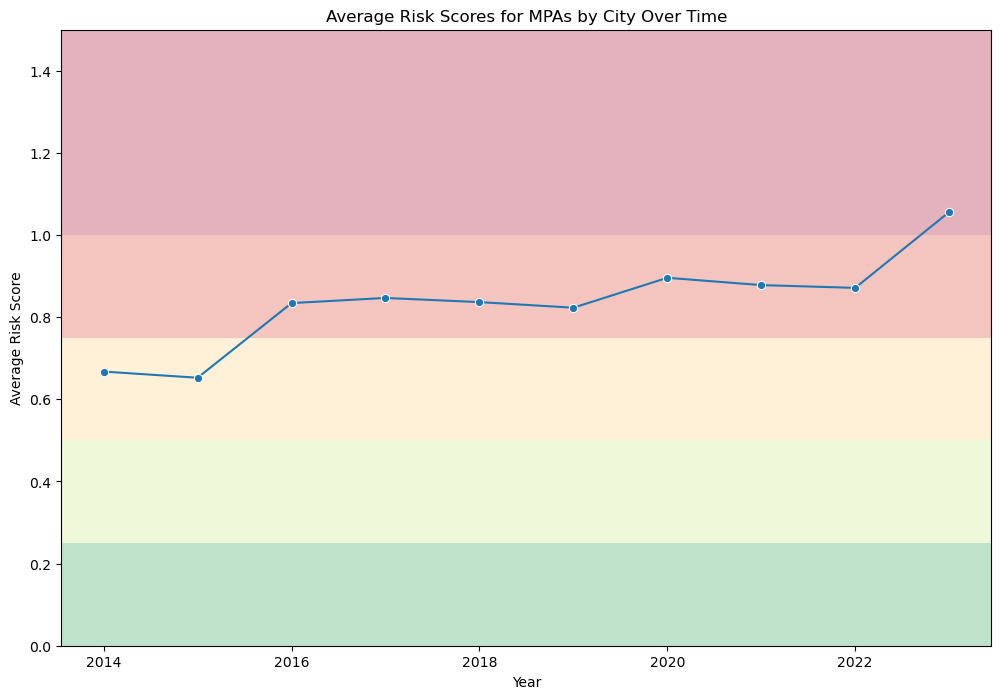

In [28]:
# Function to plot the average risk scores with smooth color bands
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

def plot_avg_risk_with_smooth_bands(df):
    plt.figure(figsize=(12, 8))

    # Plot the average risk scores for each city
    sns.lineplot(data=df, x='year', y='risk_score', marker='o')
    
    # Define risk level thresholds
    risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 2.5]
    cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
    norm = Normalize(vmin=0, vmax=1)

    # Loop through risk levels and add smooth color bands
    for i in range(len(risk_thresholds) - 1):
        plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                    facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                    alpha=0.3)

    # Set plot title and labels
    plt.title('Average Risk Scores for MPAs by City Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Risk Score')
    plt.ylim(0, 1.5)

    # Show the plot
    plt.show()

# Generate the plot with smooth color bands
plot_avg_risk_with_smooth_bands(risk_by_year)

In [29]:
mpa = gpd.read_file('E:/SILAW/MarineProtectedAreas/MarineProtectedAreas.shp')
mpa_names = risk_df['MPA_name'].unique()
mpa_deets = mpa[mpa['NAME'].isin(mpa_names)][['NAME', 'MARINE_EXI', 'LITTORAL_E', 'CORAL_EXIS', 'REEF_AREA_', 'SEAGRASS_E', 'MANGROVE_E']]
mpa_deets = mpa_deets.merge(risk_df[risk_df['risk_score'] >= 0.6][['MPA_name', 'mean_radiance', 'risk_score']], left_on='NAME', right_on='MPA_name', how='left').reset_index(drop=True)

In [30]:
mpa_deets.drop(columns=['MPA_name'], inplace=True)
mpa_deets = mpa_deets.groupby('NAME').mean()
mpa_deets.dropna(subset='mean_radiance', inplace=True)

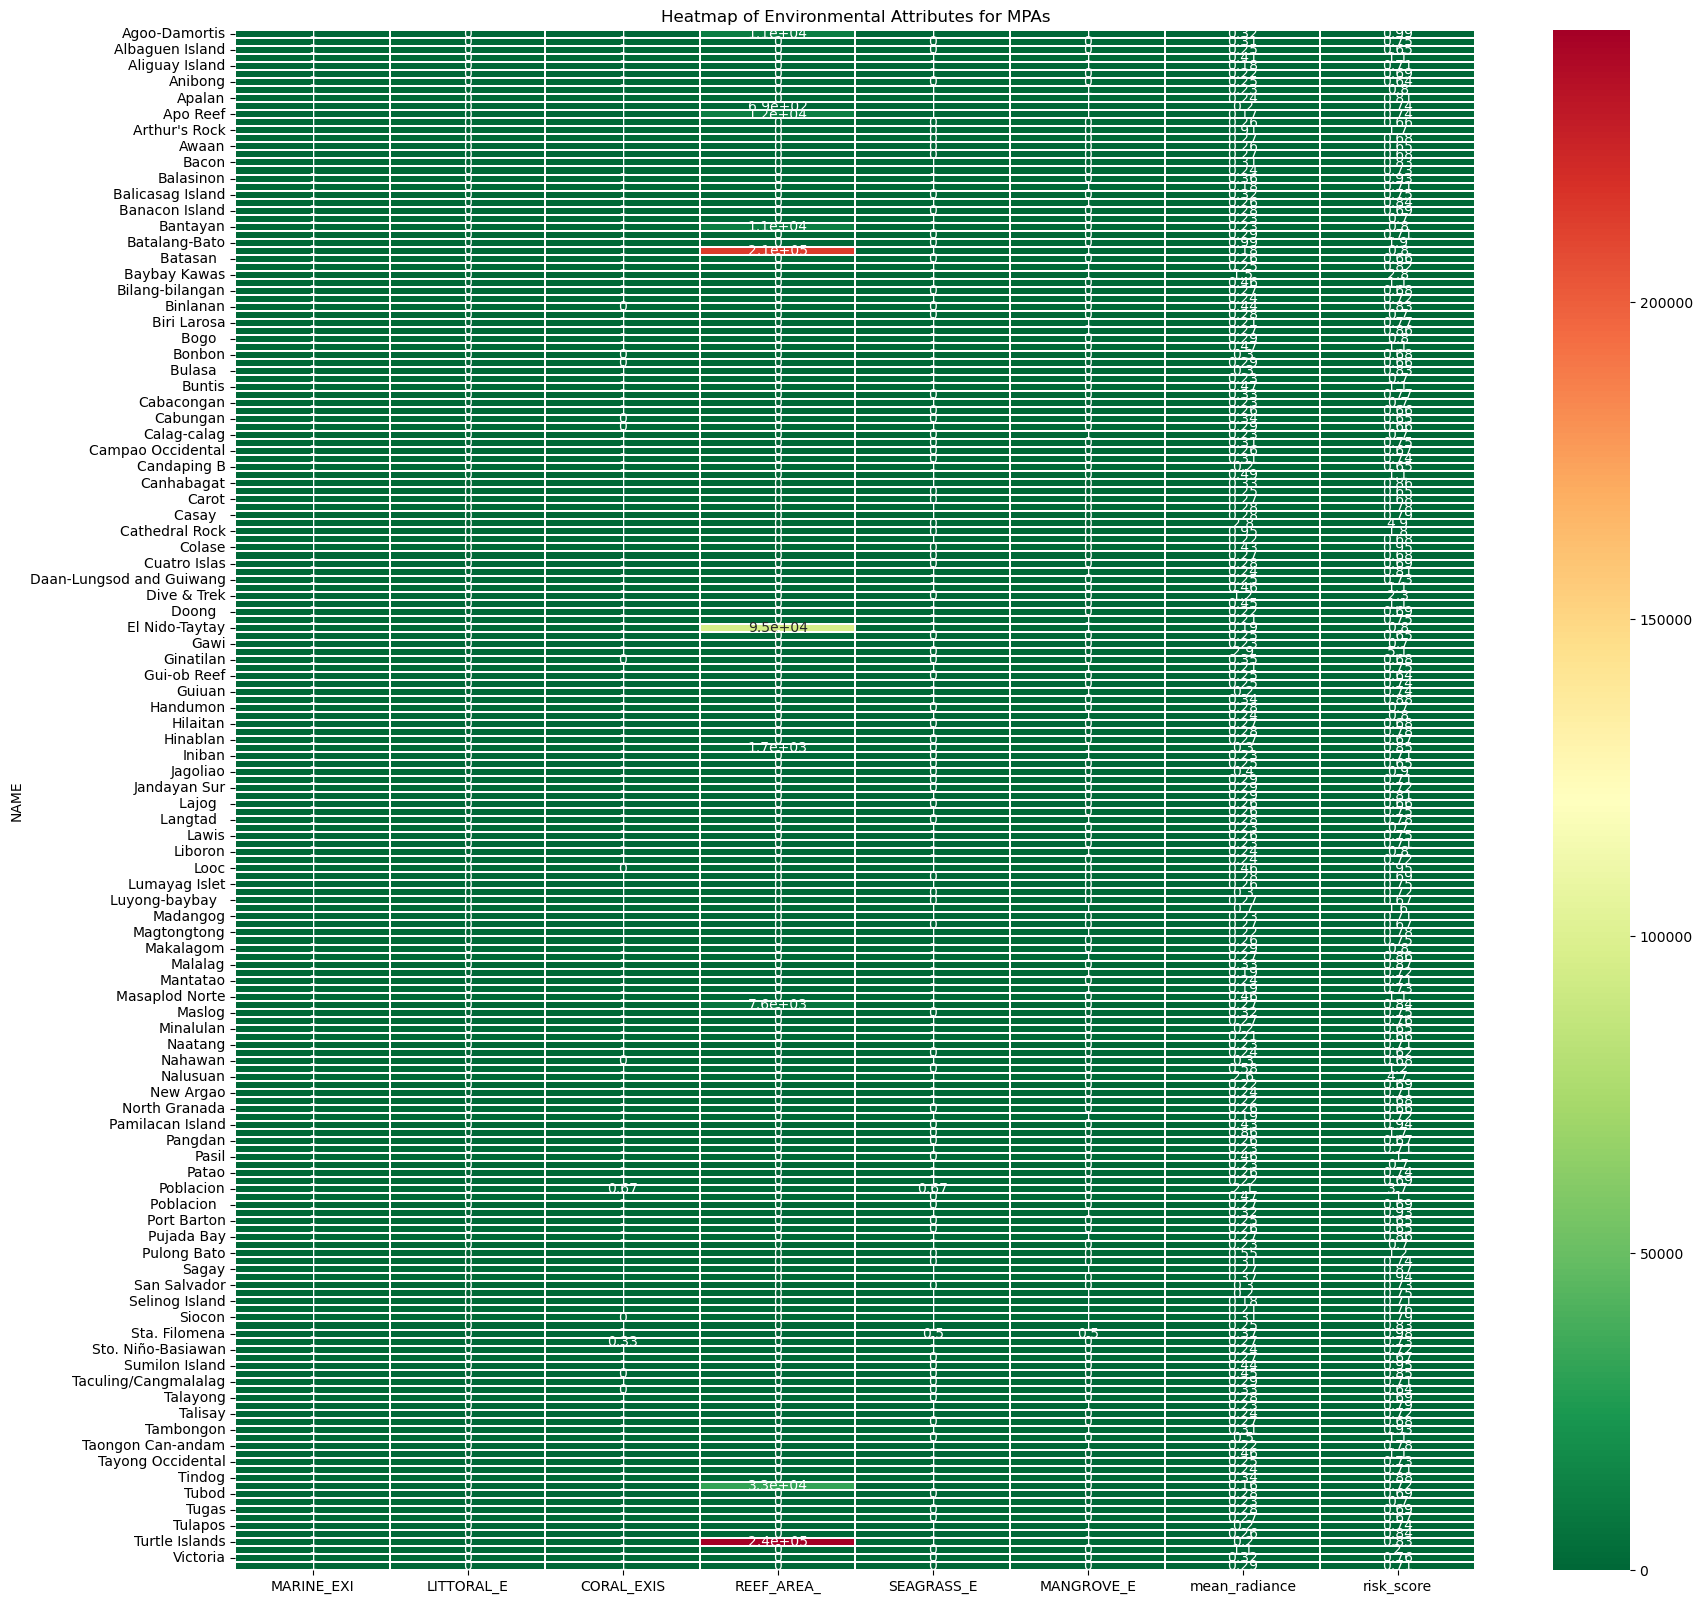

In [31]:
# Create the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(mpa_deets, annot=True, linewidths=0.1, cmap='RdYlGn_r')

# Set the title and display the plot
plt.title('Heatmap of Environmental Attributes for MPAs')
plt.show()

In [32]:
# Convert results to a GeoDataFrame for analysis
risk_gdf = gpd.GeoDataFrame(risk_results, geometry='geometry', crs="EPSG:32651")

# Save the results to a file
risk_gdf.to_file('E:/SILAW/Results_PH/risk_analysis_results_with_environmental_factors.shp')

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\3687893553.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  risk_gdf.to_file('E:/SILAW/Results_PH/risk_analysis_results_with_environmental_factors.shp')
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_radiance' to 'mean_radia'
  ogr_write(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'radiance_level' to 'radiance_l'
  ogr_write(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'normalized_radiance' to 'normalized'
  ogr_write(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'environmental_score' to 'environmen'
  ogr_write(


## Heat Maps

In [33]:
from matplotlib.colors import BoundaryNorm
import os
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

# Updated directory for saving heatmaps
heatmap_output_directory = 'E:/SILAW/Results_PH/heat_maps'
os.makedirs(heatmap_output_directory, exist_ok=True)

# VIIRS and basemap directories
viirs_directory = 'E:/SILAW/NightLights'
basemap_shapefile_path = "E:/SILAW/PH_Basemap/phl_admbnda_adm0_singlepart_psa_namria_20231106.shp"

def log_transform_viirs_data(viirs_data, constant=1e-5):
    """
    Apply log transformation to VIIRS data to compress high values and stretch low values.
    A small constant is added to avoid log(0).
    """
    return np.log1p(viirs_data + constant)  # log(1 + radiance) to avoid issues with 0 values

def generate_heatmaps_with_viirs_and_mpa(risk_gdf):
    # Use a continuous colormap transitioning from green to red
    cmap_risk = plt.get_cmap('RdYlGn_r')  # Smooth transition from green (low risk) to red (high risk)
    
    # Define boundaries for the risk categories
    boundaries = [0, 0.25, 0.5, 0.75, 1, 10]  # Risk boundaries (percentiles or thresholds)
    norm = BoundaryNorm(boundaries, cmap_risk.N)

    # Read the Philippine basemap shapefile using GeoPandas
    basemap_gdf = gpd.read_file(basemap_shapefile_path)

    # Group the risk data by year
    grouped_results = risk_gdf.groupby('year')

    # Iterate over the grouped results to generate heatmaps for each year
    for year, results in grouped_results:
        # Create figure and axes for plotting
        fig, ax = plt.subplots(figsize=(10, 10))

        # Load the corresponding VIIRS raster file (one per year)
        viirs_file_path = os.path.join(viirs_directory, f'VIIRS_{year}_Philippines_UTM.tif')

        if not os.path.exists(viirs_file_path):
            print(f"VIIRS file missing for the year {year}")
            continue

        # Open the VIIRS raster file
        with rasterio.open(viirs_file_path) as viirs_src:
            viirs_crs = viirs_src.crs

            # Reproject the basemap to match the VIIRS CRS (assuming VIIRS is in UTM)
            if basemap_gdf.crs != viirs_crs:
                print(f"Reprojecting basemap to match VIIRS CRS ({viirs_crs})")
                basemap_gdf_utm = basemap_gdf.to_crs(viirs_crs)
            else:
                basemap_gdf_utm = basemap_gdf

            # Read the entire VIIRS data in one go
            viirs_data = viirs_src.read(1)
            
            # Apply log transformation to the VIIRS data
            viirs_data_log = log_transform_viirs_data(viirs_data)
            
            # Overlay the log-transformed VIIRS data as the second layer
            show(viirs_data_log, transform=viirs_src.transform, ax=ax, cmap='gray', alpha=1.0)

            # Plot the Philippine basemap in blue outline
            basemap_gdf_utm.plot(ax=ax, color='none', edgecolor='blue', linewidth=1, alpha=0.3)

        # Set colors based on actual risk score (no normalization)
        results['color'] = results['risk_score'].apply(lambda score: cmap_risk(score))

        # Plot the MPAs with smaller size and colors based on their risk scores
        results.plot(ax=ax, color=results['color'], alpha=0.5, markersize=0.5)

        # Set the extent to cover the Philippines based on VIIRS bounds
        ax.set_xlim([viirs_src.bounds.left, viirs_src.bounds.right])
        ax.set_ylim([viirs_src.bounds.bottom, viirs_src.bounds.top])

        # Add a colorbar with green-to-red transition
        sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, boundaries=boundaries)
        cbar.set_label('Risk Score')
        cbar.set_ticks([0.125, 0.375, 0.625, 0.875, 5])
        cbar.set_ticklabels(['Low', 'Medium', 'High', 'Very High', 'Critical'])

        # Final plot touches
        ax.set_title(f"Light Pollution Risk Map for MPAs in {year}", fontsize=16)
        ax.set_axis_off()

        # Save the plot as an image in the heatmap directory
        output_file = os.path.join(heatmap_output_directory, f'heatmap_{year}.png')
        plt.savefig(output_file, bbox_inches='tight', dpi=300)
        print(f"Saved heatmap for {year} with VIIRS and MPAs to {output_file}")
        plt.close()

In [34]:
generate_heatmaps_with_viirs_and_mpa(risk_gdf)

Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2014 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2014.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2015 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2015.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2016 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2016.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2017 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2017.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2018 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2018.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2019 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_maps\heatmap_2019.png
Reprojecting basemap to match VIIRS CRS (EPSG:32651)
Saved heatmap for 2020 with VIIRS and MPAs to E:/SILAW/Results_PH/heat_

In [35]:
import cv2
import os

# Define the directory where the PNG files are located
png_directory = 'E:/SILAW/Results_PH/heat_maps'

# Define the output path for the video
output_video_path = os.path.join(png_directory, 'heatmap_animation.mp4')

# Get the list of all PNG files in the directory, sorted by filename (to maintain order)
png_files = sorted([f for f in os.listdir(png_directory) if f.endswith('.png')])

# Check if there are any PNG files
if not png_files:
    print("No PNG files found in the directory.")
else:
    # Read the first image to get the size
    first_image_path = os.path.join(png_directory, png_files[0])
    first_image = cv2.imread(first_image_path)
    height, width, layers = first_image.shape

    # Define the video codec and create a VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Define the codec (mp4)
    video = cv2.VideoWriter(output_video_path, fourcc, 1, (width, height))  # 1 FPS

    # Iterate through the PNG files and add each to the video
    for png_file in png_files:
        image_path = os.path.join(png_directory, png_file)
        image = cv2.imread(image_path)
        video.write(image)  # Add the image to the video

    # Release the video writer object
    video.release()

    print(f"Video saved as {output_video_path}")

Video saved as E:/SILAW/Results_PH/heat_maps\heatmap_animation.mp4


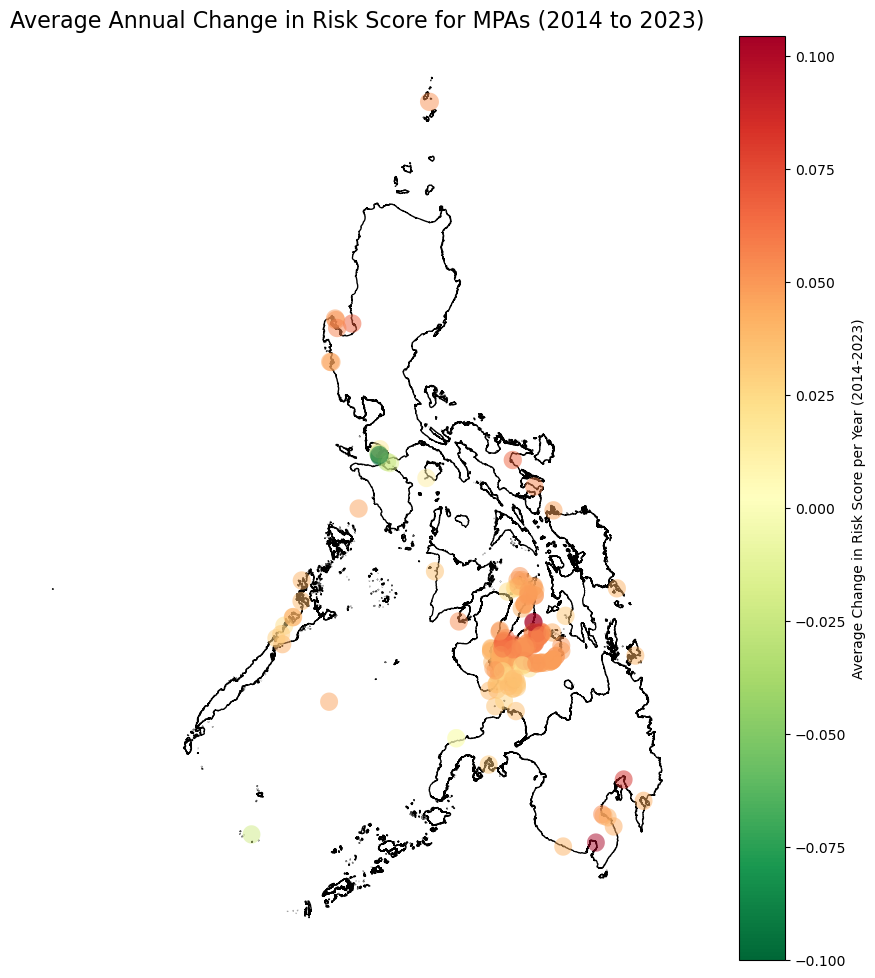

MPA average annual risk change map saved to E:/SILAW/Results_PH/combined_heatmap\mpa_average_risk_change_per_year_2014_2023.png


In [168]:
import geopandas as gpd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

# Load the basemap shapefile using GeoPandas
basemap_shapefile_path = "E:/SILAW/PH_Basemap/phl_admbnda_adm0_singlepart_psa_namria_20231106.shp"
basemap_gdf = gpd.read_file(basemap_shapefile_path)

def plot_mpa_average_risk_change_per_year(risk_gdf):
    # Ensure risk_gdf has a CRS matching the basemap (if needed)
    if risk_gdf.crs != basemap_gdf.crs:
        risk_gdf = risk_gdf.to_crs(basemap_gdf.crs)

    # Calculate the total change in risk score from 2014 to 2023 for each MPA
    change_in_risk = risk_gdf[risk_gdf['year'] == 2023].set_index('MPA_ID')['risk_score'] - \
                     risk_gdf[risk_gdf['year'] == 2014].set_index('MPA_ID')['risk_score']

    # Calculate the average change per year (total change divided by 9 years)
    average_change_per_year = change_in_risk / 9

    # Merge the average change data back into the GeoDataFrame
    risk_gdf['average_risk_change_per_year'] = risk_gdf['MPA_ID'].map(average_change_per_year)

    # Filter data to only include 2023 entries for visualization
    risk_gdf_2023 = risk_gdf[risk_gdf['year'] == 2023]

    # Create a colormap for average changes in risk scores, ensuring red indicates higher change
    cmap_change = plt.get_cmap('RdYlGn_r')  # Reversed 'RdYlGn' so more change = red
    norm = Normalize(vmin=risk_gdf['average_risk_change_per_year'].min(), vmax=risk_gdf['average_risk_change_per_year'].max())

    # Create figure and axes for plotting
    fig, ax = plt.subplots(figsize=(12, 12))

    # Plot the basemap
    basemap_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1, alpha=1)

    # Plot MPAs using the average risk change values
    risk_gdf_2023.plot(ax=ax, column='average_risk_change_per_year', cmap=cmap_change, alpha=0.5, markersize=10)

    # Add colorbar for average risk change values
    sm = plt.cm.ScalarMappable(cmap=cmap_change, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Average Change in Risk Score per Year (2014-2023)')

    # Set plot titles and labels
    ax.set_title("Average Annual Change in Risk Score for MPAs (2014 to 2023)", fontsize=16)
    ax.set_axis_off()

    # Save the figure
    output_directory = "E:/SILAW/Results_PH/combined_heatmap"
    os.makedirs(output_directory, exist_ok=True)
    output_file = os.path.join(output_directory, 'mpa_average_risk_change_per_year_2014_2023.png')
    plt.savefig(output_file, bbox_inches='tight', dpi=300)
    plt.show()

    print(f"MPA average annual risk change map saved to {output_file}")

# Assuming `risk_gdf` is your GeoDataFrame with MPA risk scores and years
plot_mpa_average_risk_change_per_year(risk_gdf)


## Modelling

### Clustering

In [38]:
risk_df.columns

Index(['year', 'MPA_ID', 'MPA_name', 'mean_radiance', 'radiance_level',
       'normalized_radiance', 'environmental_score', 'risk_score',
       'risk_level', 'geometry'],
      dtype='object')

In [39]:
yearly_risk = pd.merge(risk_df, mpa[['ID', 'LAT', 'LON', 'TYPE', 'MARINE_EXI', 'LITTORAL_E', 'CORAL_EXIS', 'REEF_AREA_', 'SEAGRASS_E', 'MANGROVE_E',]], left_on="MPA_ID", right_on="ID", how="inner")

In [40]:
yearly_risk.head()

,year,MPA_ID,MPA_name,mean_radiance,radiance_level,normalized_radiance,environmental_score,risk_score,risk_level,geometry,ID,LAT,LON,TYPE,MARINE_EXI,LITTORAL_E,CORAL_EXIS,REEF_AREA_,SEAGRASS_E,MANGROVE_E
0,2014,2813.0,Agoo-Damortis,0.154715,Moderate Light Pollution,0.515718,0.908871,0.71,High Risk,POLYGON ((235481.26926751263 1802087.618206362...,2813.0,16.278513,120.337943,Protected Landscape and Seascape,1.0,0.0,1.0,10947.0,1.0,1.0
1,2015,2813.0,Agoo-Damortis,0.162179,Moderate Light Pollution,0.540597,0.908871,0.72,High Risk,POLYGON ((235481.26926751263 1802087.618206362...,2813.0,16.278513,120.337943,Protected Landscape and Seascape,1.0,0.0,1.0,10947.0,1.0,1.0
2,2016,2813.0,Agoo-Damortis,0.248388,Moderate Light Pollution,0.827959,0.908871,0.87,Very High Risk,POLYGON ((235481.26926751263 1802087.618206362...,2813.0,16.278513,120.337943,Protected Landscape and Seascape,1.0,0.0,1.0,10947.0,1.0,1.0
3,2017,2813.0,Agoo-Damortis,0.303975,High Light Pollution,1.013249,0.908871,0.96,Very High Risk,POLYGON ((235481.26926751263 1802087.618206362...,2813.0,16.278513,120.337943,Protected Landscape and Seascape,1.0,0.0,1.0,10947.0,1.0,1.0
4,2018,2813.0,Agoo-Damortis,0.309462,High Light Pollution,1.031538,0.908871,0.97,Very High Risk,POLYGON ((235481.26926751263 1802087.618206362...,2813.0,16.278513,120.337943,Protected Landscape and Seascape,1.0,0.0,1.0,10947.0,1.0,1.0


In [41]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select relevant features
features = ['mean_radiance', 'CORAL_EXIS', 'REEF_AREA_', 'SEAGRASS_E', 'MANGROVE_E']

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(yearly_risk[features])

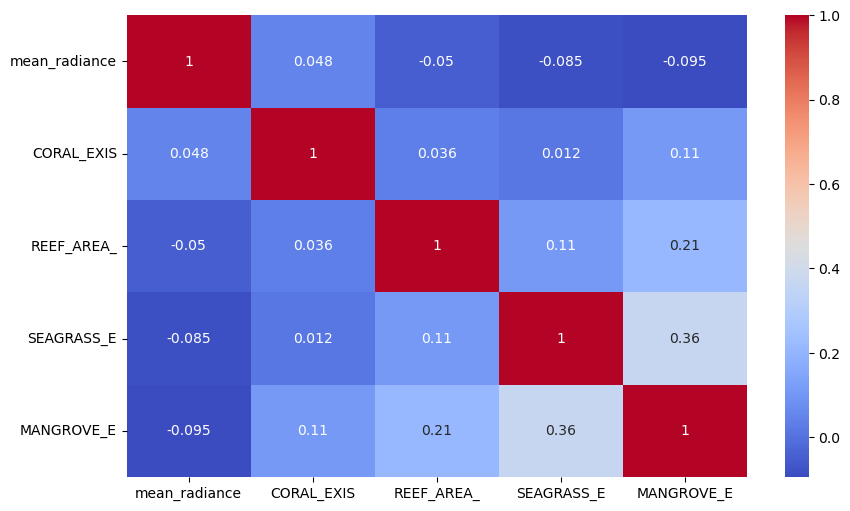

In [42]:
plt.figure(figsize=(10, 6))
corr_matrix = pd.DataFrame(scaled_data, columns=features).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

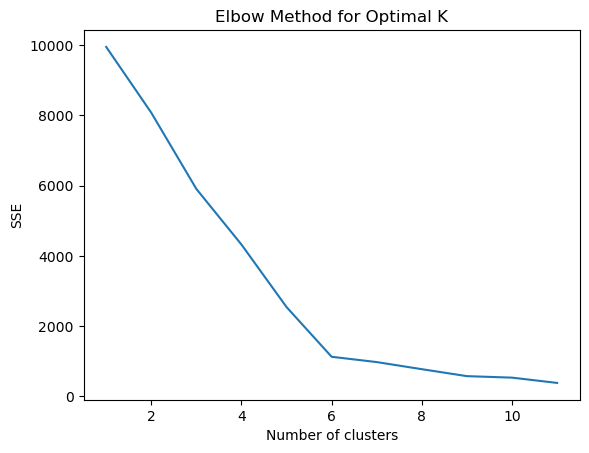

In [43]:
# Find optimal number of clusters using Elbow Method
sse = []
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(range(1, 12), sse)
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal K')
plt.show()

In [44]:
# Fit KMeans with optimal number of clusters
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++')
yearly_risk['cluster'] = kmeans.fit_predict(scaled_data)

In [45]:
yearly_risk = pd.read_csv("E:/SILAW/Results_PH/risk_clusters_PH.csv")

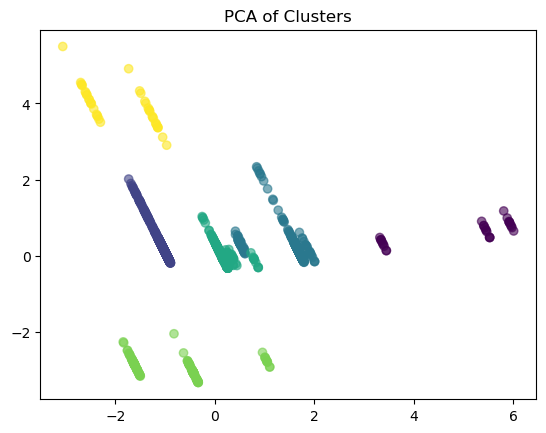

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
reduced_data = pca.fit_transform(scaled_data)

plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=yearly_risk['cluster'], cmap='viridis', alpha=0.6)
plt.title('PCA of Clusters')
plt.show()

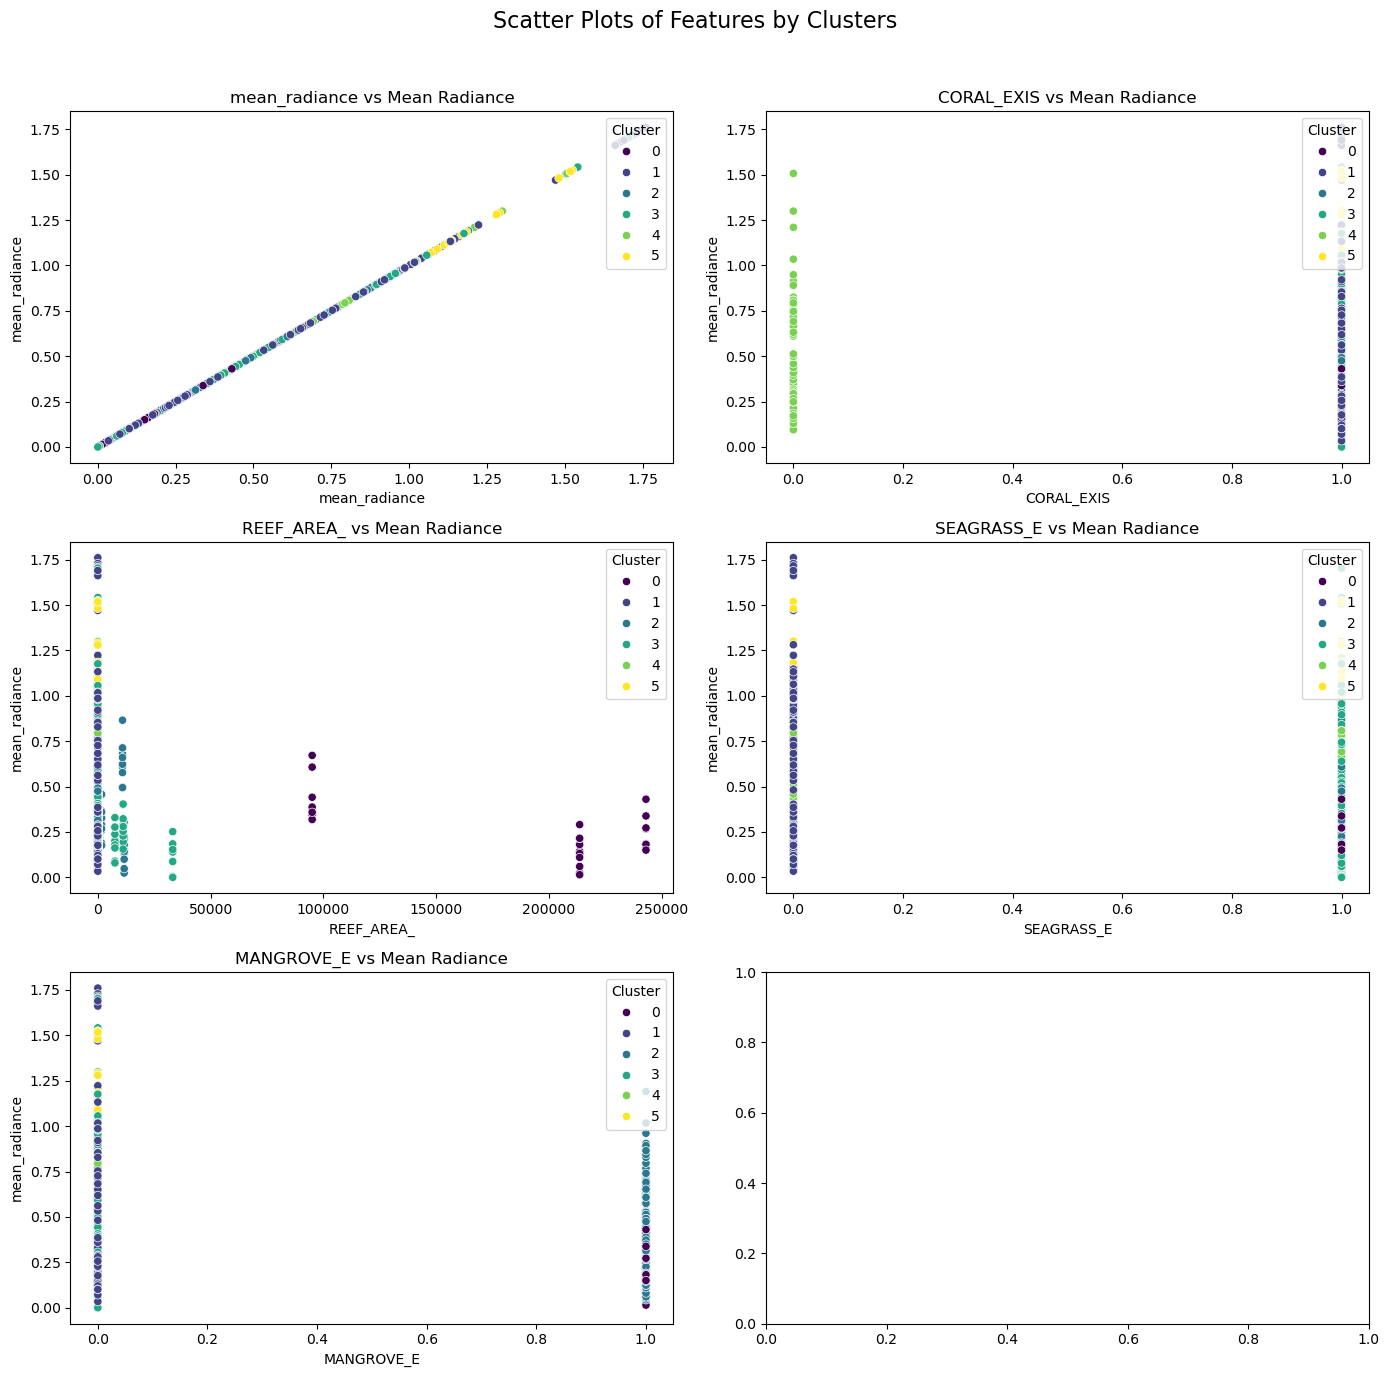

In [47]:
# Create a figure with subplots for each feature scatter plot
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
fig.suptitle('Scatter Plots of Features by Clusters', fontsize=16)

for idx, feature in enumerate(features):
    row, col = divmod(idx, 2)
    sns.scatterplot(x=feature, y='mean_radiance', hue='cluster', data=yearly_risk, palette='viridis', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Mean Radiance')
    axes[row, col].legend(title='Cluster', loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [48]:
cluster_name_mapping = {
    0: 'Reef-Seagrass Reserves',
    1: 'Balanced Coral Sanctuaries',
    2: 'Small Coral Havens',
    3: 'Mixed Ecosystem Shelters',
    4: 'Coastal Biodiversity Refuges',
    5: 'High-Risk Coral Zones'
} 

yearly_risk['cluster_label'] = yearly_risk['cluster'].copy()
yearly_risk['cluster_label'] = yearly_risk['cluster_label'].replace(cluster_name_mapping)

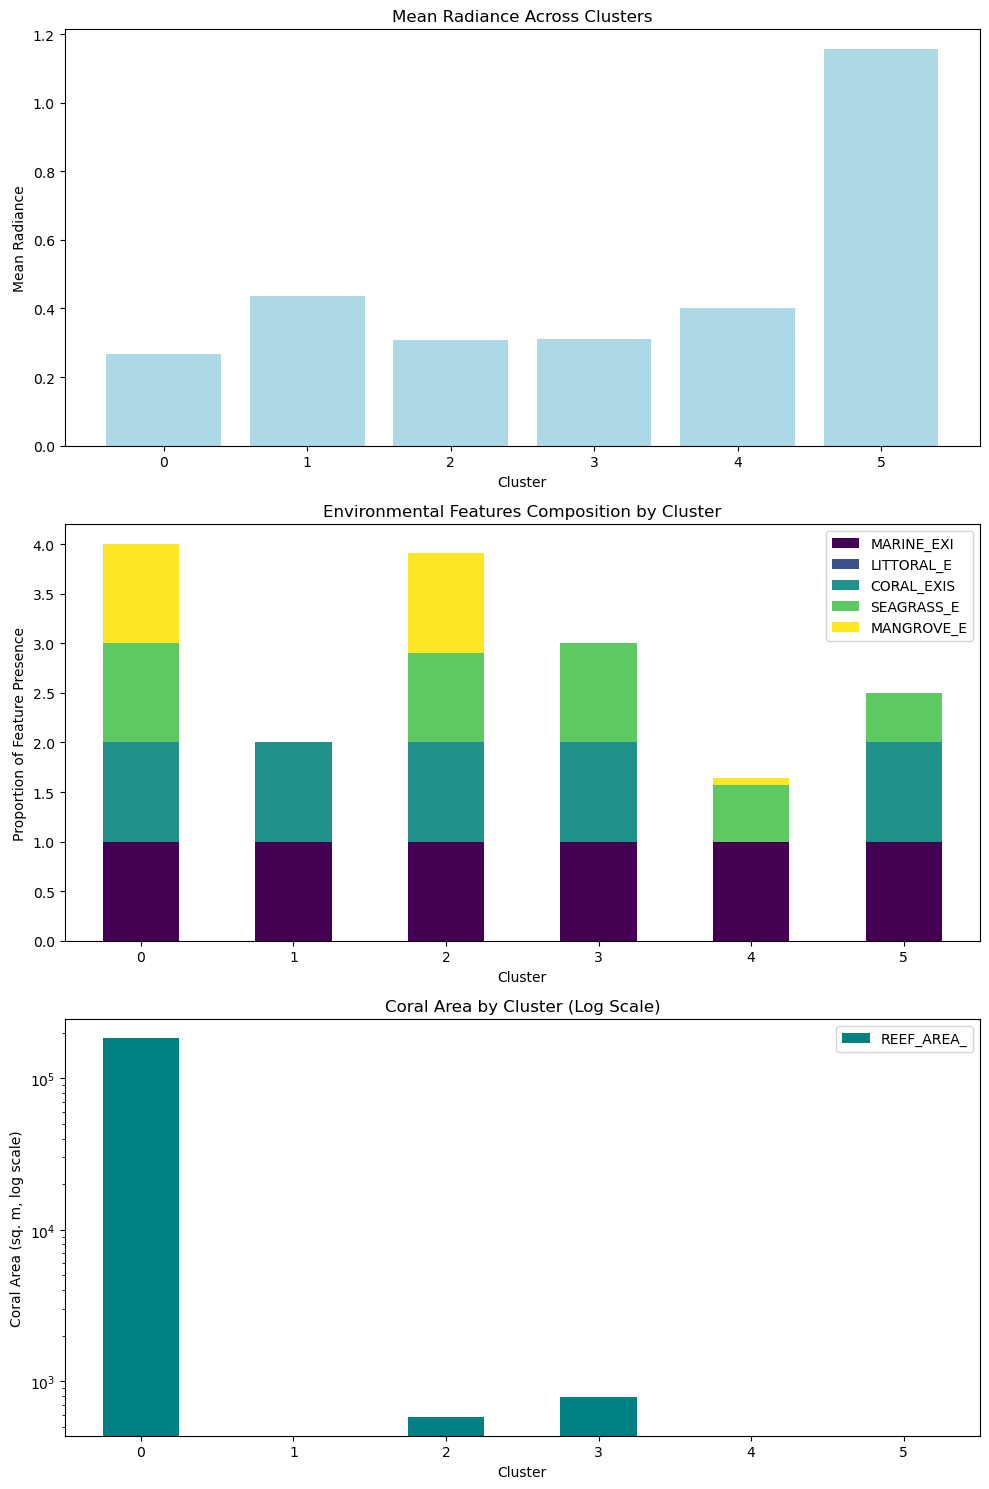

<Figure size 640x480 with 0 Axes>

In [49]:
yearly_risk_clean = yearly_risk[['cluster', 'mean_radiance', 'MARINE_EXI', 'LITTORAL_E', 'CORAL_EXIS', 'REEF_AREA_', 'SEAGRASS_E', 'MANGROVE_E',]]

# Prepare data for visualizing the clusters
cluster_means = yearly_risk_clean.groupby('cluster').mean()

# Plotting the mean radiance for each cluster
plt.figure(figsize=(10, 15))

# Subplot 1: Mean Radiance
plt.subplot(3, 1, 1)
plt.bar(cluster_means.index, cluster_means['mean_radiance'], color='lightblue')
plt.title('Mean Radiance Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Mean Radiance')

# Subplot 2: Environmental features (normalized)
plt.subplot(3, 1, 2)
cluster_means[['MARINE_EXI', 'LITTORAL_E', 'CORAL_EXIS', 'SEAGRASS_E', 'MANGROVE_E']].plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
plt.title('Environmental Features Composition by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion of Feature Presence')
plt.xticks(rotation=0)

# Subplot 3: Coral Area (logarithmic scale)
plt.subplot(3, 1, 3)
ax = plt.gca()
cluster_means[['REEF_AREA_']].plot(kind='bar', stacked=True, ax=ax, color='teal')
ax.set_yscale('log')  # Set y-axis to logarithmic scale
plt.title('Coral Area by Cluster (Log Scale)')
plt.xlabel('Cluster')
plt.ylabel('Coral Area (sq. m, log scale)')
plt.xticks(rotation=0)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
plt.savefig('E:/SILAW/Results_PH/clusters_log_scale.png', bbox_inches='tight', dpi=300)

In [50]:
yearly_risk.to_csv("E:/SILAW/Results_PH/risk_clusters_PH.csv")

#### MPAs per Cluster

MPA Shapefile CRS: EPSG:4326
Cluster Data CRS: EPSG:32651


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\3322334471.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


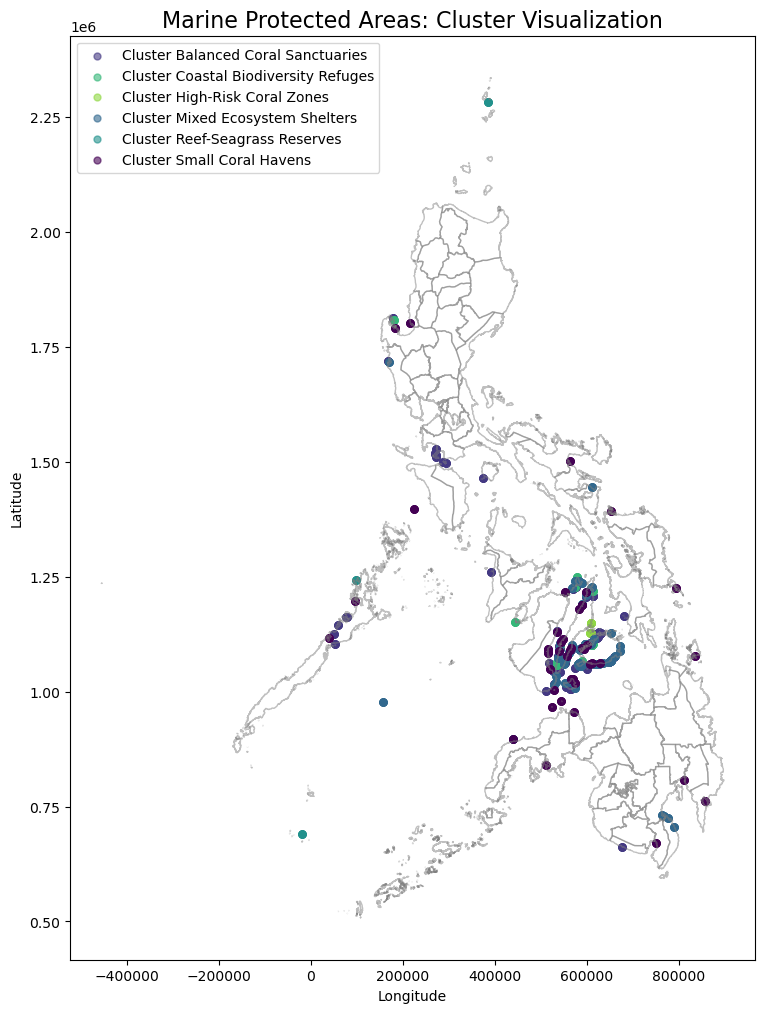

All clusters map saved at E:/SILAW/Results_PH\all_clusters_map_centroids.png


In [77]:
import geopandas as gpd
from shapely import wkt
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load the MPA shapefile
mpa_shapefile = gpd.read_file("E:/SILAW/PH_Basemap/phl_admbnda_adm2_psa_namria_20231106.shp")

# Check the CRS of the MPA shapefile
print("MPA Shapefile CRS:", mpa_shapefile.crs)

# Ensure the 'geometry' column is valid by converting from WKT if necessary
if isinstance(yearly_risk['geometry'].iloc[0], str):
    yearly_risk['geometry'] = yearly_risk['geometry'].apply(wkt.loads)

# Create a GeoDataFrame from the yearly_risk data
gdf = gpd.GeoDataFrame(yearly_risk, geometry='geometry')

# Assuming UTM, check if gdf has a CRS, if not assign UTM CRS
if gdf.crs is None:
    gdf.set_crs(epsg=32651, inplace=True)  # UTM Zone 51N for the Philippines

# Check the CRS of both datasets
print("Cluster Data CRS:", gdf.crs)

# Ensure the CRS of the MPA shapefile matches the gdf
if mpa_shapefile.crs != gdf.crs:
    mpa_shapefile = mpa_shapefile.to_crs(gdf.crs)

# Calculate centroids for non-point geometries
gdf['centroid'] = gdf.geometry.centroid
centroids = gdf.set_geometry('centroid')

# Create a colormap using Viridis
cmap = cm.get_cmap('viridis')
unique_labels = centroids['cluster_label'].unique()
colors = {label: cmap(i / len(unique_labels)) for i, label in enumerate(unique_labels)}

# Plotting all clusters in one map
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the MPA boundaries
mpa_shapefile.boundary.plot(ax=ax, linewidth=1, color='grey', alpha=0.5)

# Plot clusters using centroids with Viridis colormap
for label, data in centroids.groupby('cluster_label'):
    ax.scatter(
        data.geometry.x, 
        data.geometry.y, 
        label=f'Cluster {label}', 
        color=colors[label], 
        s=25,  # Adjust the marker size as needed
        alpha=0.6
    )

# Set aspect ratio to equal
ax.set_aspect('equal')

# Add title and labels
plt.title('Marine Protected Areas: Cluster Visualization', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add legend
plt.legend()

# Save the figure as a PNG
output_directory = "E:/SILAW/Results_PH"
os.makedirs(output_directory, exist_ok=True)
output_path = os.path.join(output_directory, 'all_clusters_map_centroids.png')
plt.savefig(output_path, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

print(f"All clusters map saved at {output_path}")


In [78]:
yearly_risk.to_csv("E:/SILAW/Results_PH/risk_clusters_PH.csv", index=False)

#### MPAs that Changed Clusters

In [79]:
yearly_risk = pd.read_csv("E:/SILAW/Results_PH/risk_clusters_PH.csv")

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\583973245.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=mpas_with_changes_data, x='year', y='cluster', hue='ID', marker='o', palette='viridis', alpha=0.5)
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\583973245.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


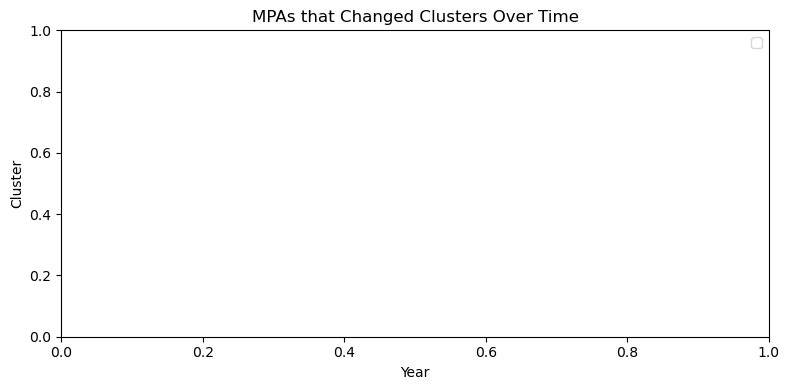

In [80]:
yearly_risk['year'] = pd.to_datetime(yearly_risk['year'], format='%Y')

# Filter only MPAs that have more than 1 unique cluster (indicating a change)
mpa_cluster_changes = yearly_risk.groupby('ID')['cluster'].nunique()
mpas_with_changes = mpa_cluster_changes[mpa_cluster_changes > 1].index

# Filter the main DataFrame to include only those MPAs that changed clusters
mpas_with_changes_data = yearly_risk[yearly_risk['ID'].isin(mpas_with_changes)]

# Plot the changes for each MPA
plt.figure(figsize=(8, 4))

# Use Seaborn's lineplot to visualize the cluster changes over time
sns.lineplot(data=mpas_with_changes_data, x='year', y='cluster', hue='ID', marker='o', palette='viridis', alpha=0.5)

# Customize the plot
plt.title('MPAs that Changed Clusters Over Time')
plt.xlabel('Year')
plt.ylabel('Cluster')
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


In [81]:
mpas_with_changes_data[['MPA_ID','MPA_name']].groupby('MPA_ID').value_counts()

Series([], Name: count, dtype: int64)

### Silhouette Scors

In [82]:
from sklearn.metrics import silhouette_samples, silhouette_score

# Extract the features
X = yearly_risk[features]

# Compute the silhouette scores
silhouette_avg = silhouette_score(scaled_data, yearly_risk['cluster'])
print(f"Average silhouette score: {silhouette_avg}")

# Compute silhouette scores for each sample
sample_silhouette_values = silhouette_samples(scaled_data, yearly_risk['cluster'])

Average silhouette score: 0.7501578740262043


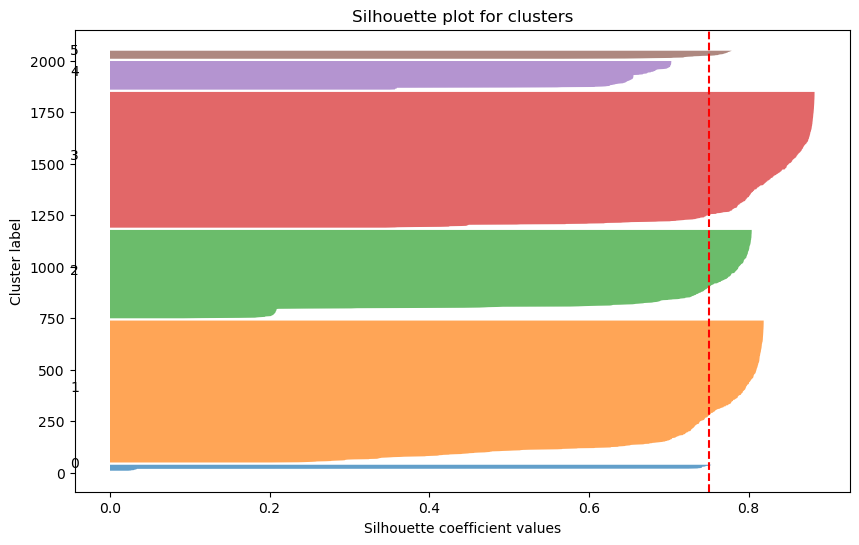

In [83]:
# Plot silhouette scores for each cluster
fig, ax1 = plt.subplots(figsize=(10, 6))

y_lower = 10
for i in range(len(np.unique(yearly_risk['cluster']))):
    ith_cluster_silhouette_values = sample_silhouette_values[yearly_risk['cluster'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10  # 10 for the 0 samples gap between clusters

ax1.set_title("Silhouette plot for clusters")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster label")

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()

### Risk Score Plots Per Cluster

In [84]:
yearly_risk = pd.read_csv('E:/SILAW/Results_PH/risk_clusters_PH.csv')

In [85]:
avg_risk_by_cluster = yearly_risk.groupby(['cluster', 'year'])['risk_score'].mean().reset_index()

In [86]:
def plot_avg_risk_with_smooth_bands(df):
    plt.figure(figsize=(12, 8))

    # Plot the average risk scores for each city
    sns.lineplot(data=avg_risk_by_cluster, x='year', y='risk_score', hue='cluster', marker='o', palette='viridis')
    
    # Define risk level thresholds
    risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
    cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
    norm = Normalize(vmin=0, vmax=1)

    # Loop through risk levels and add smooth color bands
    for i in range(len(risk_thresholds) - 1):
        plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                    facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                    alpha=0.3)

    # Set plot title and labels
    plt.title('Average Risk Scores for MPAs by Cluster Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Risk Score')
    plt.ylim(0, 3)

    # Show the plot
    plt.show()


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\4084074399.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap


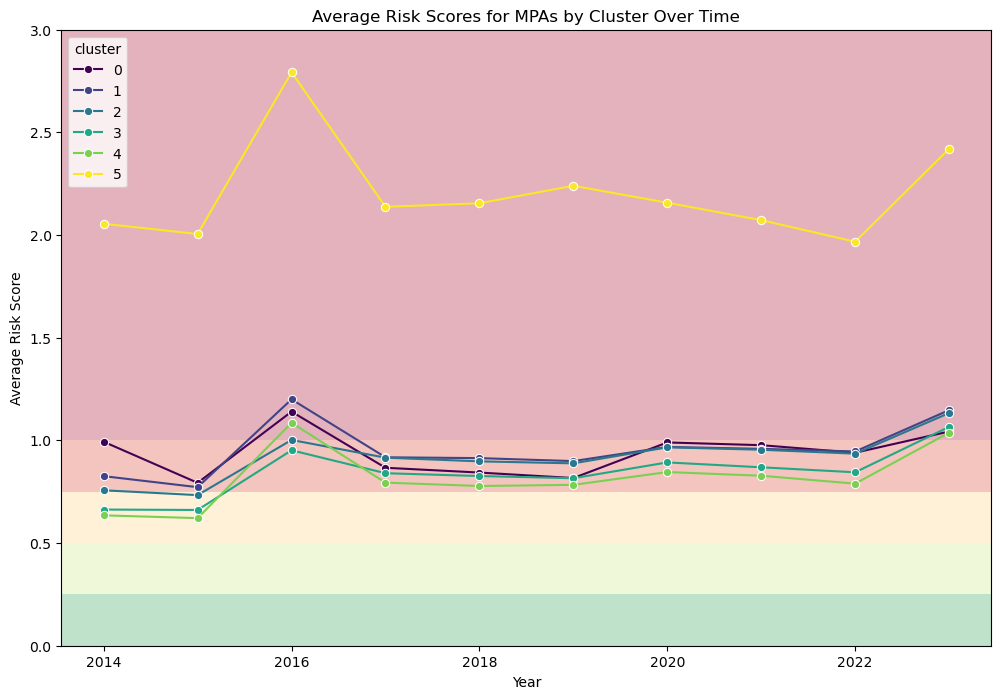

In [87]:
# Generate the plot with smooth color bands
plot_avg_risk_with_smooth_bands(avg_risk_by_cluster)

## Time Series Forecasting

### ARIMA for Yearly All Data

In [88]:
pip install statsmodels

In [89]:
yearly_risk = pd.read_csv("E:/SILAW/Results_PH/risk_clusters_PH.csv")

In [90]:
yearly_risk_overall = yearly_risk.groupby("year")["risk_score"].mean().reset_index()

In [162]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split the data into training (2014-2022) and test (2023)
train_data = yearly_risk_overall[yearly_risk_overall['year'] <= 2022]  # Corrected to include 2022 in training set
test_data = yearly_risk_overall[yearly_risk_overall['year'] == 2023]  # Test set for 2023

# Fit ARIMA model on training data (2014-2022)
model = ARIMA(train_data['risk_score'], order=(1,1,1))
model_fit = model.fit()

# Forecast for 2023 with confidence intervals
forecast_with_ci = model_fit.get_forecast(steps=1)  # Forecast one step for 2023
forecast_value_with_ci = forecast_with_ci.predicted_mean
confidence_intervals = forecast_with_ci.conf_int()

# Extract lower and upper bounds for the 2023 forecast
lower_bound = confidence_intervals.iloc[0, 0]
upper_bound = confidence_intervals.iloc[0, 1]

print(f"Forecast for 2023: {forecast_value_with_ci.iloc[0]}")
print(f"95% Confidence Interval for 2023: [{lower_bound}, {upper_bound}]")

Forecast for 2023: 0.9024261978175103
95% Confidence Interval for 2023: [0.6866231428242868, 1.1182292528107338]


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\3994267706.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap


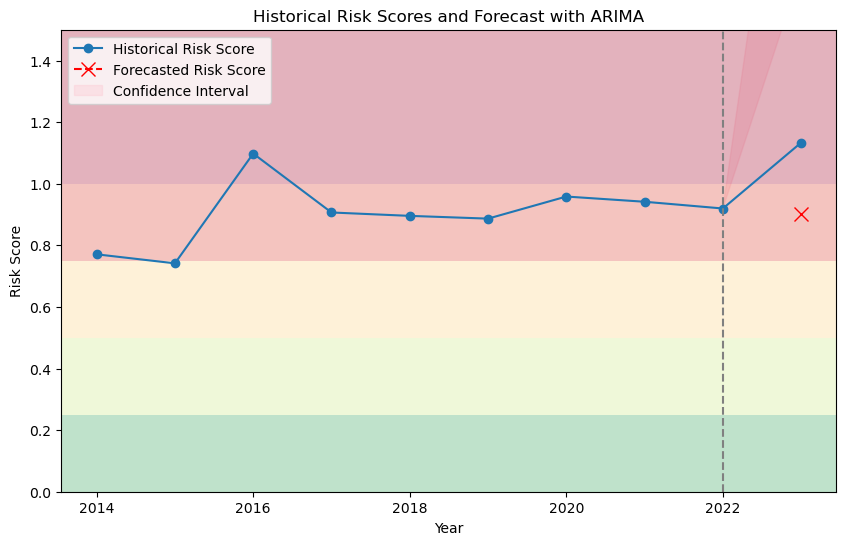

<Figure size 640x480 with 0 Axes>

In [160]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# Plot the historical data, forecast, and confidence intervals
plt.figure(figsize=(10, 6))

# Historical data from 2014-2022
plt.plot(yearly_risk_overall['year'], 
         yearly_risk_overall['risk_score'], 
         marker='o', label='Historical Risk Score')

# Forecast for 2023
plt.plot([2023], forecast_value_with_ci, marker='x', linestyle='--', color='red', 
         label='Forecasted Risk Score', markersize=10)

# Confidence Interval for the forecast
plt.fill_between([2022, 2023], [yearly_risk_overall[yearly_risk_overall['year'] == 2022]['risk_score'].values[0], lower_bound], 
                 [yearly_risk_overall[yearly_risk_overall['year'] == 2022]['risk_score'].values[0], upper_bound], 
                 color='pink', alpha=0.3, label='Confidence Interval')

# Mark the boundary between historical and forecasted data
plt.axvline(x=2022, color='gray', linestyle='--')  

# Define risk level thresholds
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 2.75]
cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Loop through risk levels and add smooth color bands
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

plt.ylim(0, 1.5)
plt.title('Historical Risk Scores and Forecast with ARIMA')
plt.xlabel('Year')
plt.ylabel('Risk Score')
plt.legend()
plt.show()

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/arima_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

#### Model Evaluation

In [117]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
# Calculate error metrics
mae_arima = mean_absolute_error(test_data['risk_score'], forecast_value_with_ci)
rmse_arima = root_mean_squared_error(test_data['risk_score'], forecast_value_with_ci)

# Display the evaluation results
print(f"ARIMA MAE: {mae_arima}")
print(f"ARIMA RMSE: {rmse_arima}")

ARIMA MAE: 0.23119189263475093
ARIMA RMSE: 0.23119189263475093


### ARIMA per Cluster

In [118]:
# Group the data by cluster and year to get the average risk_score per year for each cluster
clustered_data = yearly_risk.groupby(['cluster', 'year'])['risk_score'].mean().reset_index()

In [119]:
clusters = range(0, 6)

# Initialize a dictionary to store forecast results
cluster_forecasts = {}

# Loop through each cluster and fit an ARIMA model
for cluster in clusters:
    # Filter data for the current cluster
    cluster_data = clustered_data[clustered_data['cluster'] == cluster]

    # Split data into training (2014-2022) and testing (2023)
    train_data = cluster_data[cluster_data['year'] <= 2022]  # Updated to include 2022 in training
    test_data = cluster_data[cluster_data['year'] == 2023]   # Test set for 2023

    # Fit ARIMA model (order (1,1,1) as an initial guess)
    model = ARIMA(train_data['risk_score'], order=(1, 1, 1))
    model_fit = model.fit()
    
    # Forecast for 2023 with confidence intervals
    forecast_with_ci = model_fit.get_forecast(steps=1)  # Forecast one step ahead for 2023
    forecast_value = forecast_with_ci.predicted_mean
    confidence_intervals = forecast_with_ci.conf_int()

    # Extract lower and upper bounds for 2023
    lower_bound = confidence_intervals.iloc[0, 0]
    upper_bound = confidence_intervals.iloc[0, 1]
    
    # Store the forecast result and confidence intervals for this cluster
    cluster_forecasts[cluster] = {
        'forecast': forecast_value.iloc[0],  # Extract the forecast value as a scalar
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

# Display forecast results
for cluster, forecast_data in cluster_forecasts.items():
    print(f"Cluster {cluster}:")
    print(f"  Forecast for 2023: {forecast_data['forecast']}")
    print(f"  95% Confidence Interval: [{forecast_data['lower_bound']}, {forecast_data['upper_bound']}]")

c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported ind

Cluster 0:
  Forecast for 2023: 0.9227618383375885
  95% Confidence Interval: [0.713485418341907, 1.13203825833327]
Cluster 1:
  Forecast for 2023: 0.9332052760715058
  95% Confidence Interval: [0.6952230115233218, 1.1711875406196899]
Cluster 2:
  Forecast for 2023: 0.9351486226306894
  95% Confidence Interval: [0.7497554331282547, 1.120541812133124]
Cluster 3:
  Forecast for 2023: 0.8239634786370396
  95% Confidence Interval: [0.6255107028015029, 1.0224162544725761]
Cluster 4:
  Forecast for 2023: 0.7969237282121381
  95% Confidence Interval: [0.5211142880798179, 1.0727331683444583]
Cluster 5:
  Forecast for 2023: 2.1952818970175514
  95% Confidence Interval: [1.6922973524212748, 2.698266441613828]


c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmo

#### Model Evaluation

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize dictionaries to store RMSE and MAE results for each cluster
cluster_rmse = {}
cluster_mae = {}

# Loop through each cluster to calculate RMSE and MAE
for cluster in clusters:
    # Extract the actual values for 2023 from the original dataset
    actual_2023 = clustered_data[(clustered_data['cluster'] == cluster) & 
                                 (clustered_data['year'] == 2023)]['risk_score'].values

    # Extract the forecasted value for 2023
    forecasted_2023 = cluster_forecasts[cluster]['forecast']

    # Check if actual_2023 is available
    if len(actual_2023) > 0:
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(actual_2023, [forecasted_2023]))  # forecasted_2023 is wrapped in a list to match shape
        mae = mean_absolute_error(actual_2023, [forecasted_2023])  # Same here for MAE
    else:
        rmse = np.nan
        mae = np.nan

    # Store the results
    cluster_rmse[cluster] = rmse
    cluster_mae[cluster] = mae

# Display RMSE and MAE for each cluster
for cluster in clusters:
    print(f"Cluster {cluster}:")
    print(f"  RMSE for 2023 forecast: {cluster_rmse[cluster]}")
    print(f"  MAE for 2023 forecast: {cluster_mae[cluster]}")


Cluster 0:
  RMSE for 2023 forecast: 0.12057149499574471
  MAE for 2023 forecast: 0.12057149499574471
Cluster 1:
  RMSE for 2023 forecast: 0.21418602827632027
  MAE for 2023 forecast: 0.21418602827632027
Cluster 2:
  RMSE for 2023 forecast: 0.19810719132279908
  MAE for 2023 forecast: 0.19810719132279908
Cluster 3:
  RMSE for 2023 forecast: 0.24194561227205136
  MAE for 2023 forecast: 0.24194561227205136
Cluster 4:
  RMSE for 2023 forecast: 0.24093341464500473
  MAE for 2023 forecast: 0.24093341464500473
Cluster 5:
  RMSE for 2023 forecast: 0.22471810298244854
  MAE for 2023 forecast: 0.22471810298244854


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\2689077664.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_threshold = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap


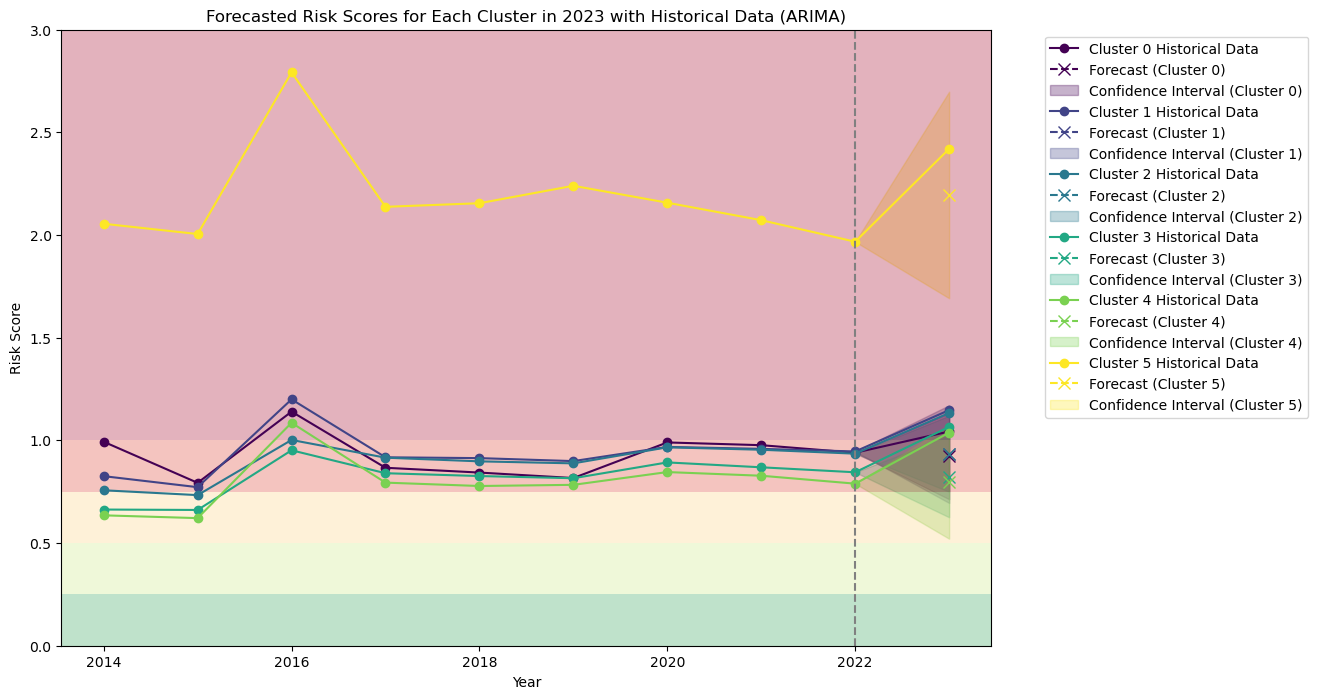

<Figure size 640x480 with 0 Axes>

In [132]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import numpy as np

# Generate a colormap from viridis
cmap = plt.get_cmap('viridis', len(clusters))
colors = [cmap(i) for i in range(len(clusters))]

# Initialize lists for confidence intervals, extracting from cluster_forecasts
lower_bounds = [cluster_forecasts[cluster]['lower_bound'] for cluster in clusters]
upper_bounds = [cluster_forecasts[cluster]['upper_bound'] for cluster in clusters]

# Plot the historical data, forecasts, and confidence intervals for each cluster
plt.figure(figsize=(12, 8))

# Loop through each cluster and plot historical data and forecasts
for idx, cluster in enumerate(clusters):
    # Filter data for the current cluster
    cluster_data = clustered_data[clustered_data['cluster'] == cluster]

    # Plot historical data (2014-2022)
    plt.plot(cluster_data['year'], 
             cluster_data['risk_score'], 
             marker='o', color=colors[idx], label=f'Cluster {cluster} Historical Data')
    
    # Plot the forecasted risk score for 2023
    forecast_value = cluster_forecasts[cluster]['forecast']
    plt.plot([2023], [forecast_value], marker='x', linestyle='--', color=colors[idx], 
             label=f'Forecast (Cluster {cluster})', markersize=8)
    
    # Plot confidence intervals for the forecast
    plt.fill_between([2022, 2023], 
                     [cluster_data[cluster_data['year'] == 2022]['risk_score'].values[0], lower_bounds[idx]], 
                     [cluster_data[cluster_data['year'] == 2022]['risk_score'].values[0], upper_bounds[idx]], 
                     color=colors[idx], alpha=0.3, label=f'Confidence Interval (Cluster {cluster})')

# Add a vertical line to mark the transition from historical to forecast
plt.axvline(x=2022, color='gray', linestyle='--')

# Define risk level thresholds for adding color bands
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
cmap_threshold = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Loop through risk levels and add smooth color bands
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap_threshold(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.5)
# Set plot titles and labels
plt.ylim(0, 3)
plt.title('Forecasted Risk Scores for Each Cluster in 2023 with Historical Data (ARIMA)')
plt.xlabel('Year')
plt.ylabel('Risk Score')
plt.show()

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/arima_cluster_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

#### 5-year Forecast

c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported ind

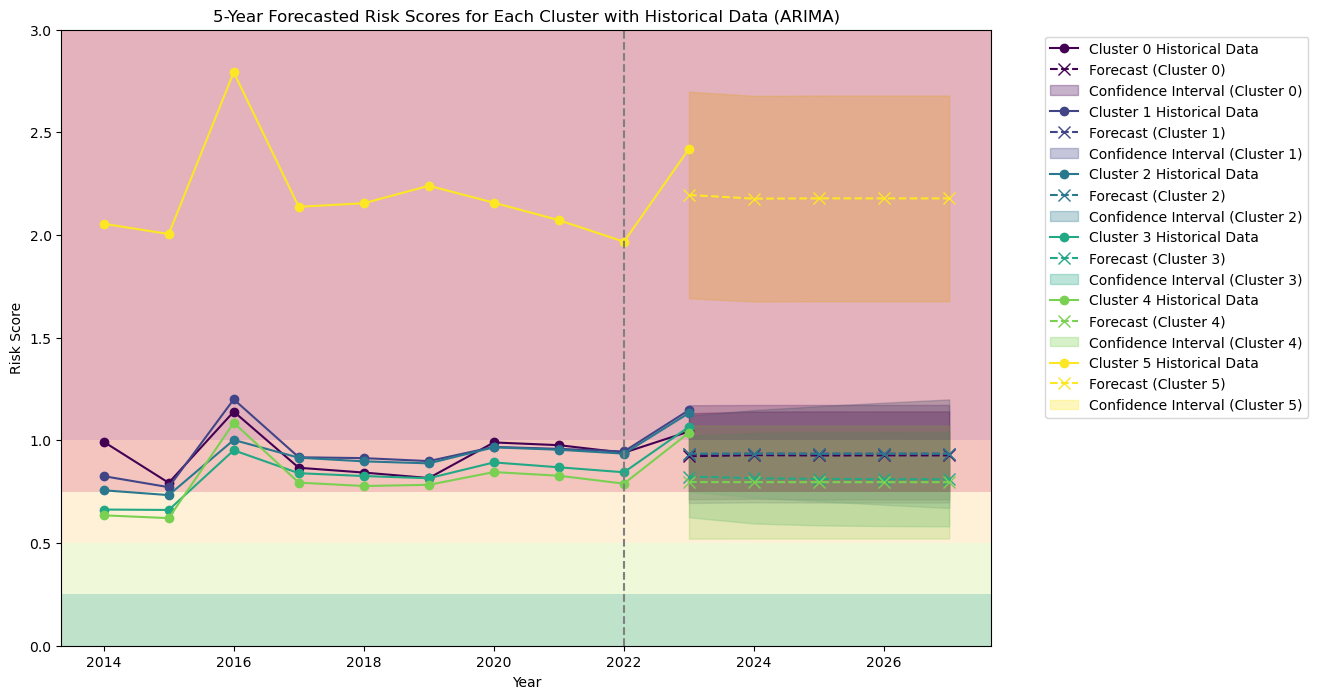

<Figure size 640x480 with 0 Axes>

In [133]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import numpy as np

# Generate a colormap from viridis
cmap = plt.get_cmap('viridis', len(clusters))
colors = [cmap(i) for i in range(len(clusters))]

# Initialize lists for forecasted values and confidence intervals
forecasted_values = {}
lower_bounds = {}
upper_bounds = {}

# Loop through each cluster and fit an ARIMA model to generate a 5-year forecast
for cluster in clusters:
    # Filter data for the current cluster
    cluster_data = clustered_data[clustered_data['cluster'] == cluster]

    # Split data into training (2014-2022)
    train_data = cluster_data[cluster_data['year'] <= 2022]

    # Fit ARIMA model (order (1,1,1) as an initial guess)
    model = ARIMA(train_data['risk_score'], order=(1, 1, 1))
    model_fit = model.fit()
    
    # Forecast for the next 5 years
    forecast_with_ci = model_fit.get_forecast(steps=5)
    forecast_values = forecast_with_ci.predicted_mean
    confidence_intervals = forecast_with_ci.conf_int()

    # Store the forecast results and confidence intervals
    forecasted_values[cluster] = forecast_values
    lower_bounds[cluster] = confidence_intervals.iloc[:, 0].values
    upper_bounds[cluster] = confidence_intervals.iloc[:, 1].values

# Plot the historical data, forecasts, and confidence intervals for each cluster
plt.figure(figsize=(12, 8))

# Define forecast years
forecast_years = [2023, 2024, 2025, 2026, 2027]

# Loop through each cluster and plot historical data and forecasts
for idx, cluster in enumerate(clusters):
    # Filter data for the current cluster
    cluster_data = clustered_data[clustered_data['cluster'] == cluster]

    # Plot historical data (2014-2022)
    plt.plot(cluster_data['year'], 
             cluster_data['risk_score'], 
             marker='o', color=colors[idx], label=f'Cluster {cluster} Historical Data')
    
    # Plot the forecasted risk scores for the next 5 years
    plt.plot(forecast_years, forecasted_values[cluster], marker='x', linestyle='--', color=colors[idx], 
             label=f'Forecast (Cluster {cluster})', markersize=8)
    
    # Plot confidence intervals for the forecasts
    plt.fill_between(forecast_years, lower_bounds[cluster], upper_bounds[cluster], 
                     color=colors[idx], alpha=0.3, label=f'Confidence Interval (Cluster {cluster})')

# Add a vertical line to mark the transition from historical to forecast
plt.axvline(x=2022, color='gray', linestyle='--')

# Define risk level thresholds for adding color bands
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
cmap_threshold = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Loop through risk levels and add smooth color bands
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap_threshold(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.5)
# Set plot titles and labels
plt.ylim(0, 3)
plt.title('5-Year Forecasted Risk Scores for Each Cluster with Historical Data (ARIMA)')
plt.xlabel('Year')
plt.ylabel('Risk Score')
plt.show()

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/arima_5year_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)


### Prophet

In [123]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [124]:
from prophet import Prophet

# Load your yearly data (adjust path as needed)
yearly_risk = pd.read_csv(("E:/SILAW/Results_PH/risk_clusters_PH.csv"))
yearly_data = yearly_risk.groupby("year")["risk_score"].mean().reset_index()

In [137]:
# Prepare the data for Prophet ('ds' for dates, 'y' for risk scores)
yearly_data = yearly_data.rename(columns={'year': 'ds', 'risk_score': 'y'})
yearly_data['ds'] = pd.to_datetime(yearly_data['ds'], format='%Y')

# Split the data into train and test sets
train_data = yearly_data[yearly_data['ds'] <= '2022-01-01']  # Training data up to 2022
test_data = yearly_data[yearly_data['ds'] == '2023-01-01']   # Test data for 2023

# Initialize and fit Prophet model on the train data
model = Prophet()
model.fit(train_data)

# Create a future dataframe for 1 year (2023) for testing
future = model.make_future_dataframe(periods=1, freq='Y')

# Forecast future values
forecast = model.predict(future)

# Display the forecast for 2023
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(1))

20:49:41 - cmdstanpy - INFO - Chain [1] start processing
20:49:42 - cmdstanpy - INFO - Chain [1] done processing


          ds      yhat  yhat_lower  yhat_upper
9 2022-12-31  1.291529    1.194761      1.3901


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\2997165133.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap


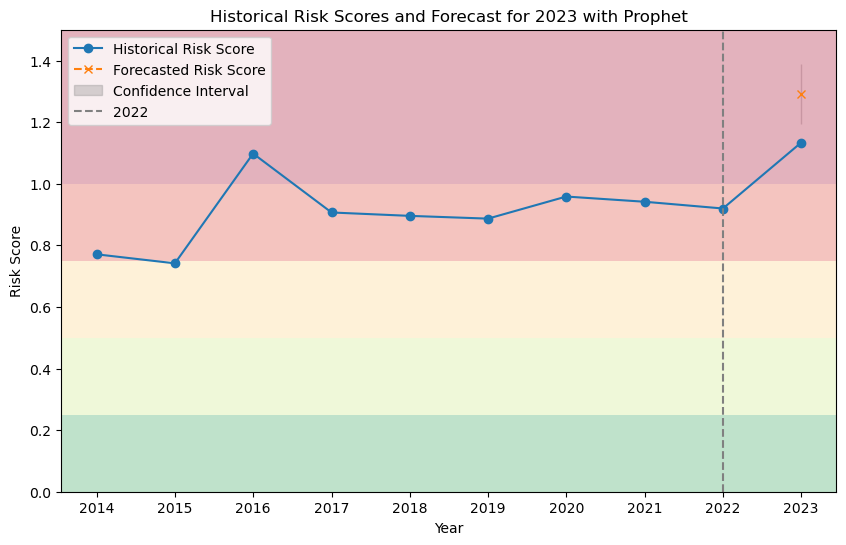

<Figure size 640x480 with 0 Axes>

In [138]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import pandas as pd
import numpy as np

# Plot the historical risk scores and forecast
plt.figure(figsize=(10, 6))

# Plot historical data (2014-2022)
plt.plot(yearly_data['ds'], 
         yearly_data['y'], 
         marker='o', label='Historical Risk Score')

# Plot forecast for 2023
forecast_2023 = forecast[forecast['ds'] > '2022-01-01']
plt.plot(forecast_2023['ds'], forecast_2023['yhat'], marker='x', linestyle='--', label='Forecasted Risk Score')

# Plot the confidence interval for the forecast
plt.fill_between(forecast_2023['ds'], forecast_2023['yhat_lower'], forecast_2023['yhat_upper'], color='gray', alpha=0.3, label='Confidence Interval')

# Define risk level thresholds for color bands
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Loop through risk levels and add smooth color bands
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

# Add a vertical line to separate historical data from the forecast
plt.axvline(pd.to_datetime('2022-01-01'), color='gray', linestyle='--', label='2022')

# Set plot titles and labels
plt.ylim(0, 1.5)
plt.title('Historical Risk Scores and Forecast for 2023 with Prophet')
plt.xlabel('Year')
plt.ylabel('Risk Score')
plt.legend()

# Show the plot
plt.show()

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/prophet_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)


#### Model Evaluation

In [139]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Extract the actual values for 2023 from the test data
actual_2023 = test_data['y'].values

# Extract the forecasted value for 2023
forecasted_2023 = forecast_2023['yhat'].values

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_2023, forecasted_2023))
print(f"RMSE for the 2023 forecast: {rmse}")

# Calculate MAE
mae = mean_absolute_error(actual_2023, forecasted_2023)
print(f"MAE for the 2023 forecast: {mae}")

RMSE for the 2023 forecast: 0.1579113258142697
MAE for the 2023 forecast: 0.1579113258142697


### Prophet per Cluster

In [140]:
# Load your yearly data (adjust path as needed)
yearly_risk = pd.read_csv(("E:/SILAW/Results_PH/risk_clusters_PH.csv"))
yearly_data_cluster = yearly_risk.groupby(["cluster", "year"])["risk_score"].mean().reset_index()

In [141]:
# Initialize a dictionary to store the forecast results per cluster
cluster_prophet_forecasts = {}

# Get the unique clusters
clusters = yearly_data_cluster['cluster'].unique()

# Loop through each cluster and fit a Prophet model
for cluster in clusters:
    # Filter the data for the current cluster
    cluster_data = yearly_data_cluster[yearly_data_cluster['cluster'] == cluster]
    
    # Prepare the data for Prophet ('ds' for dates, 'y' for risk scores)
    cluster_data = cluster_data.rename(columns={'year': 'ds', 'risk_score': 'y'})
    cluster_data['ds'] = pd.to_datetime(cluster_data['ds'], format='%Y')
    
    # Split the data into train (up to 2022) and test (2023) sets
    train_data = cluster_data[cluster_data['ds'] <= '2022-01-01']  

    # Initialize and fit Prophet model on the train data
    model = Prophet()
    model.fit(train_data[['ds', 'y']])
    
    # Create a future dataframe for 1 year (2023) for testing
    future = model.make_future_dataframe(periods=1, freq='Y')
    
    # Forecast future values for 2023
    forecast = model.predict(future)
    
    # Extract the forecast for 2023 along with confidence intervals
    forecast_2023 = forecast[forecast['ds'] > '2022-01-01']
    
    # Store the forecast result for the current cluster including confidence intervals
    cluster_prophet_forecasts[cluster] = forecast_2023[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

20:50:15 - cmdstanpy - INFO - Chain [1] start processing
20:50:15 - cmdstanpy - INFO - Chain [1] done processing
20:50:15 - cmdstanpy - INFO - Chain [1] start processing
20:50:15 - cmdstanpy - INFO - Chain [1] done processing
20:50:15 - cmdstanpy - INFO - Chain [1] start processing
20:50:16 - cmdstanpy - INFO - Chain [1] done processing
20:50:16 - cmdstanpy - INFO - Chain [1] start processing
20:50:16 - cmdstanpy - INFO - Chain [1] done processing
20:50:16 - cmdstanpy - INFO - Chain [1] start processing
20:50:16 - cmdstanpy - INFO - Chain [1] done processing
20:50:17 - cmdstanpy - INFO - Chain [1] start processing
20:50:17 - cmdstanpy - INFO - Chain [1] done processing


#### Model Evaluation

In [142]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize dictionaries to store RMSE and MAE results per cluster
cluster_rmse = {}
cluster_mae = {}

# Loop through each cluster to calculate RMSE and MAE
for cluster in clusters:
    # Extract actual values for 2023 from the original dataset
    actual_2023 = yearly_data_cluster[(yearly_data_cluster['cluster'] == cluster) & 
                                      (yearly_data_cluster['year'] == 2023)]['risk_score'].values

    # Extract forecasted value for 2023
    forecast_2023 = cluster_prophet_forecasts[cluster]['yhat'].values

    # Calculate RMSE
    if len(actual_2023) > 0 and len(forecast_2023) > 0:
        rmse = np.sqrt(mean_squared_error(actual_2023, forecast_2023))
        mae = mean_absolute_error(actual_2023, forecast_2023)
    else:
        rmse = np.nan
        mae = np.nan

    # Store the results
    cluster_rmse[cluster] = rmse
    cluster_mae[cluster] = mae

# Display RMSE and MAE for each cluster
for cluster in clusters:
    print(f"Cluster {cluster}:")
    print(f"  RMSE for 2023 forecast: {cluster_rmse[cluster]}")
    print(f"  MAE for 2023 forecast: {cluster_mae[cluster]}")

Cluster 0:
  RMSE for 2023 forecast: 0.13936363409209052
  MAE for 2023 forecast: 0.13936363409209052
Cluster 1:
  RMSE for 2023 forecast: 0.17431427251547715
  MAE for 2023 forecast: 0.17431427251547715
Cluster 2:
  RMSE for 2023 forecast: 0.1394068593307689
  MAE for 2023 forecast: 0.1394068593307689
Cluster 3:
  RMSE for 2023 forecast: 0.12424809449598806
  MAE for 2023 forecast: 0.12424809449598806
Cluster 4:
  RMSE for 2023 forecast: 0.17489040162461622
  MAE for 2023 forecast: 0.17489040162461622
Cluster 5:
  RMSE for 2023 forecast: 0.5072865731563696
  MAE for 2023 forecast: 0.5072865731563696


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\1678583551.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['year'] = pd.to_datetime(cluster_data['year'], format='%Y')
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\1678583551.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['year'] = pd.to_datetime(cluster_data['year'], format='%Y')
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\1678583551.py:20: SettingWithCopyWarning: 
A value is trying to be 

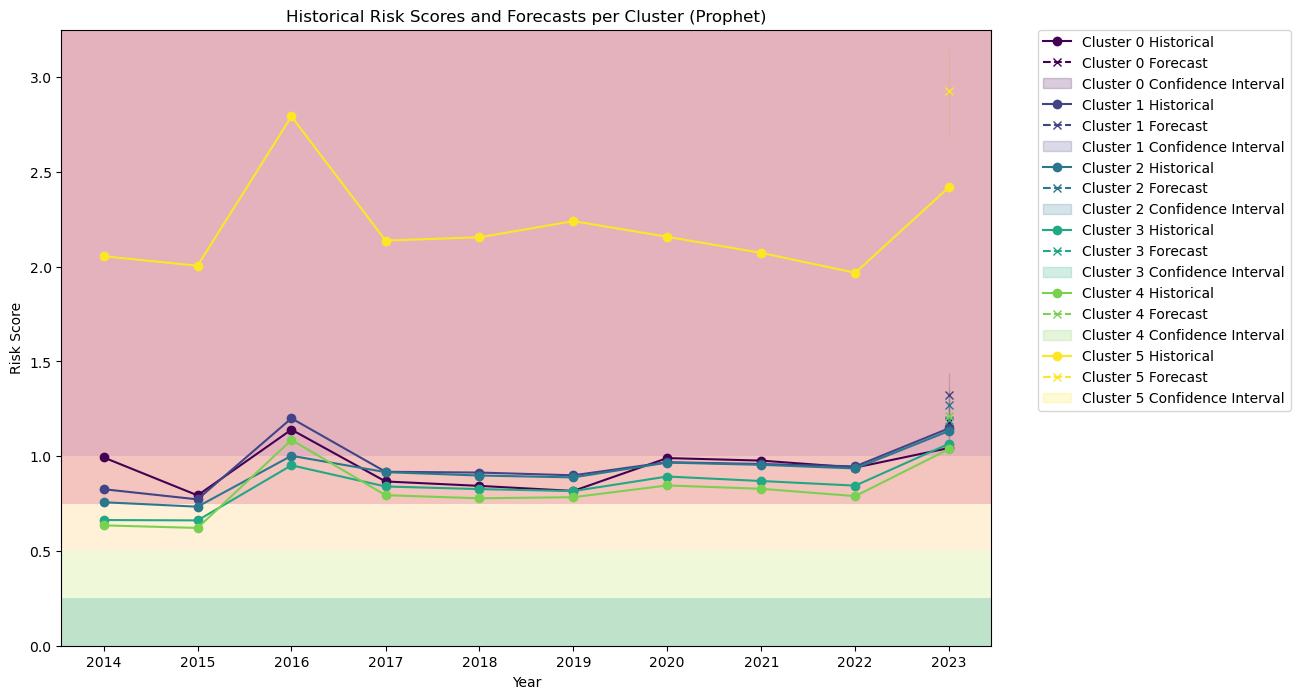

In [143]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# Get the unique clusters
clusters = yearly_data_cluster['cluster'].unique()

# Generate colors for each cluster
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Initialize the plot
plt.figure(figsize=(12, 8))

# Loop through each cluster and plot the historical data and forecasts
for idx, cluster in enumerate(clusters):
    # Filter the historical data for the current cluster
    cluster_data = yearly_data_cluster[yearly_data_cluster['cluster'] == cluster]
    cluster_data['year'] = pd.to_datetime(cluster_data['year'], format='%Y')

    # Plot the historical data
    plt.plot(cluster_data['year'], cluster_data['risk_score'], marker='o', color=colors[idx], label=f'Cluster {cluster} Historical')

    # Get the forecasts for the cluster
    forecasts = cluster_prophet_forecasts[cluster]

    # Plot the forecasted value for 2023
    plt.plot(forecasts['ds'], forecasts['yhat'], marker='x', color=colors[idx], label=f'Cluster {cluster} Forecast', linestyle='--')

    # Plot the confidence interval for the forecast
    plt.fill_between(forecasts['ds'], forecasts['yhat_lower'], forecasts['yhat_upper'], color=colors[idx], alpha=0.2, label=f'Cluster {cluster} Confidence Interval')

# Define risk level thresholds for color bands
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Add smooth color bands representing risk thresholds
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

# Set plot titles and labels
plt.ylim(0, 3.25)
plt.title('Historical Risk Scores and Forecasts per Cluster (Prophet)')
plt.xlabel('Year')
plt.ylabel('Risk Score')

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/prophet_cluster_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

#### 5-year Forecast

20:50:58 - cmdstanpy - INFO - Chain [1] start processing
20:50:58 - cmdstanpy - INFO - Chain [1] done processing
20:50:58 - cmdstanpy - INFO - Chain [1] start processing
20:50:58 - cmdstanpy - INFO - Chain [1] done processing
20:50:59 - cmdstanpy - INFO - Chain [1] start processing
20:50:59 - cmdstanpy - INFO - Chain [1] done processing
20:50:59 - cmdstanpy - INFO - Chain [1] start processing
20:50:59 - cmdstanpy - INFO - Chain [1] done processing
20:50:59 - cmdstanpy - INFO - Chain [1] start processing
20:51:00 - cmdstanpy - INFO - Chain [1] done processing
20:51:00 - cmdstanpy - INFO - Chain [1] start processing
20:51:00 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_26288\4194453626.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

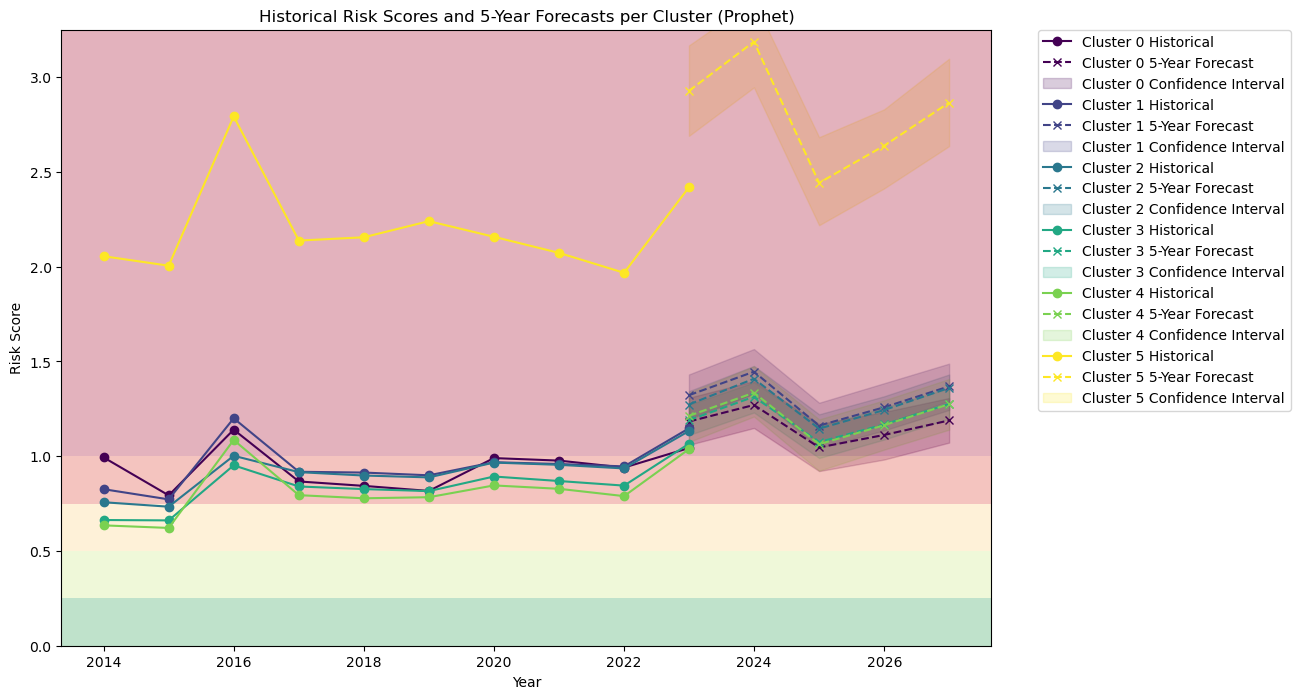

In [144]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# Initialize a dictionary to store the 5-year forecast results per cluster
cluster_prophet_forecasts_5year = {}

# Get the unique clusters
clusters = yearly_data_cluster['cluster'].unique()

# Generate colors for each cluster
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Loop through each cluster and fit a Prophet model
for cluster in clusters:
    # Filter the data for the current cluster
    cluster_data = yearly_data_cluster[yearly_data_cluster['cluster'] == cluster]
    
    # Prepare the data for Prophet ('ds' for dates, 'y' for risk scores)
    cluster_data = cluster_data.rename(columns={'year': 'ds', 'risk_score': 'y'})
    cluster_data['ds'] = pd.to_datetime(cluster_data['ds'], format='%Y')
    
    # Split the data into train (up to 2022) sets
    train_data = cluster_data[cluster_data['ds'] <= '2022-01-01']  

    # Initialize and fit Prophet model on the train data
    model = Prophet()
    model.fit(train_data[['ds', 'y']])
    
    # Create a future dataframe for the next 5 years (2023-2027)
    future = model.make_future_dataframe(periods=5, freq='Y')
    
    # Forecast future values for the next 5 years
    forecast = model.predict(future)
    
    # Extract the forecast results
    forecast_5year = forecast[forecast['ds'] > '2022-01-01']
    
    # Store the forecast result for the current cluster including confidence intervals
    cluster_prophet_forecasts_5year[cluster] = forecast_5year[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Plot the historical data, 5-year forecasts, and confidence intervals for each cluster
plt.figure(figsize=(12, 8))

# Loop through each cluster and plot the data
for idx, cluster in enumerate(clusters):
    # Filter the historical data for the current cluster
    cluster_data = yearly_data_cluster[yearly_data_cluster['cluster'] == cluster]
    cluster_data['year'] = pd.to_datetime(cluster_data['year'], format='%Y')

    # Plot the historical data
    plt.plot(cluster_data['year'], cluster_data['risk_score'], marker='o', color=colors[idx], label=f'Cluster {cluster} Historical')

    # Get the 5-year forecasts for the cluster
    forecasts = cluster_prophet_forecasts_5year[cluster]

    # Plot the forecasted values for the next 5 years
    plt.plot(forecasts['ds'], forecasts['yhat'], marker='x', color=colors[idx], linestyle='--', label=f'Cluster {cluster} 5-Year Forecast')

    # Plot the confidence interval for the forecasts
    plt.fill_between(forecasts['ds'], forecasts['yhat_lower'], forecasts['yhat_upper'], color=colors[idx], alpha=0.2, label=f'Cluster {cluster} Confidence Interval')

# Define risk level thresholds for color bands
risk_thresholds = [0, 0.25, 0.5, 0.75, 1, 10]
cmap = get_cmap('RdYlGn_r')  # Smooth red-to-green colormap
norm = Normalize(vmin=0, vmax=1)

# Add smooth color bands representing risk thresholds
for i in range(len(risk_thresholds) - 1):
    plt.axhspan(risk_thresholds[i], risk_thresholds[i + 1],
                facecolor=cmap(norm((risk_thresholds[i] + risk_thresholds[i + 1]) / 2)), 
                alpha=0.3)

# Set plot titles and labels
plt.ylim(0, 3.25)
plt.title('Historical Risk Scores and 5-Year Forecasts per Cluster (Prophet)')
plt.xlabel('Year')
plt.ylabel('Risk Score')

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Save the plot as a PNG file
output_path = 'E:/SILAW/Results_PH/prophet_5year_forecast.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()
